<a href="https://colab.research.google.com/github/2010626140/pIC50-calculation/blob/main/Final_PaDEL_Descriptor_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
print(pd.__version__)
print(np.__version__)

2.2.2
2.0.2


In [ ]:
# Read BindingDB HER2 dataset

df = pd.read_csv(
    "BindingDB_HER2.tsv",
    sep="\t",
    low_memory=False
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (5319, 640)


In [ ]:
df.head()

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51164775,COc1cc2c(Nc3ccc(Oc4ccn5ncnc5c4)c(C)c3)ncnc2cc1...,InChI=1S/C49H55N11O7/c1-32-25-34(10-13-41(32)6...,IQCKLHMMRZVWLF-UHFFFAOYSA-N,50654486,CHEMBL6132997,Receptor tyrosine-protein kinase erbB-2,Homo sapiens,NaN,0.040000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,583407,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,InChI=1S/C46H43N11O7/c1-53-23-29(18-36(53)43(5...,GOCWFVHBXZZUFO-UHFFFAOYSA-N,304254,"US10143695, Compound 78",Receptor tyrosine-protein kinase erbB-2,Human,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51506159,CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nccc(n3)-...,InChI=1S/C29H31N7O/c1-21-5-10-25(18-27(21)34-2...,KTUFNOKKBVMGRW-UHFFFAOYSA-N,13530,4-[(4-methylpiperazin-1-yl)methyl]-N-[4-methyl...,Receptor tyrosine-protein kinase erbB-2,Human,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,583412,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,InChI=1S/C42H42N12O7/c1-23-11-28-18-44-30-16-3...,WADINQPENZTYJF-UHFFFAOYSA-N,304255,"US10143695, Compound 79",Receptor tyrosine-protein kinase erbB-2,Human,NaN,0.090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,583342,COC(=O)c1ccc2n(ccc2c1)C(=O)c1cc(NC(=O)c2cc(NC(...,InChI=1S/C45H44N10O9/c1-25-14-30-20-46-32-19-3...,GTOFWJWVXHASRF-UHFFFAOYSA-N,304241,"US10143695, Compound 8A",Receptor tyrosine-protein kinase erbB-2,Human,NaN,0.140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display all column names with index numbers

for i, col in enumerate(df.columns):
    print(f"{i:3d} : {col}")

  0 : BindingDB Reactant_set_id
  1 : Ligand SMILES
  2 : Ligand InChI
  3 : Ligand InChI Key
  4 : BindingDB MonomerID
  5 : BindingDB Ligand Name
  6 : Target Name
  7 : Target Source Organism According to Curator or DataSource
  8 : Ki (nM)
  9 : IC50 (nM)
 10 : Kd (nM)
 11 : EC50 (nM)
 12 : kon (M-1-s-1)
 13 : koff (s-1)
 14 : pH
 15 : Temp (C)
 16 : Curation/DataSource
 17 : Article DOI
 18 : BindingDB Entry DOI
 19 : PMID
 20 : PubChem AID
 21 : Patent Number
 22 : Authors
 23 : Date of publication
 24 : Date in BindingDB
 25 : Institution
 26 : Link to Ligand in BindingDB
 27 : Link to Target in BindingDB
 28 : Link to Ligand-Target Pair in BindingDB
 29 : Ligand HET ID in PDB
 30 : PDB ID(s) for Ligand-Target Complex
 31 : PubChem CID
 32 : PubChem SID
 33 : ChEBI ID of Ligand
 34 : ChEMBL ID of Ligand
 35 : DrugBank ID of Ligand
 36 : IUPHAR_GRAC ID of Ligand
 37 : KEGG ID of Ligand
 38 : ZINC ID of Ligand
 39 : Number of Protein Chains in Target (>1 implies a multichain compl

In [ ]:
print("Missing IC50 values:")
print(df["IC50 (nM)"].isna().sum())

Missing IC50 values:
209


In [ ]:
df["IC50 (nM)"].astype(str).head(20)

,IC50 (nM)
0,0.040000
1,0.060
2,0.060000
3,0.090
4,0.140
5,0.140000
6,0.150
7,0.150
8,0.160
9,0.180


In [ ]:
ic50 = df["IC50 (nM)"].astype(str)

print("Contains '>' :", ic50.str.contains(">").sum())
print("Contains '<' :", ic50.str.contains("<").sum())
print("Contains '=' :", ic50.str.contains("=").sum())
print("Contains '~' :", ic50.str.contains("~").sum())

Contains '>' : 352
Contains '<' : 292
Contains '=' : 0
Contains '~' : 0


In [ ]:
# Total number of rows
total = len(df)

# Missing IC50
missing = df["IC50 (nM)"].isna().sum()

# Censored values
greater = df["IC50 (nM)"].astype(str).str.contains(">").sum()
less = df["IC50 (nM)"].astype(str).str.contains("<").sum()

# Remaining rows
remaining = total - missing - greater - less

print(f"Total compounds          : {total}")
print(f"Missing IC50             : {missing}")
print(f"Contains '>'             : {greater}")
print(f"Contains '<'             : {less}")
print("-"*40)
print(f"Estimated remaining rows : {remaining}")

Total compounds          : 5319
Missing IC50             : 209
Contains '>'             : 352
Contains '<'             : 292
----------------------------------------
Estimated remaining rows : 4466


In [ ]:
df["Target Name"].value_counts()

,count
Target Name,
Receptor tyrosine-protein kinase erbB-2,4901
"Receptor tyrosine-protein kinase erbB-2 [1-775,'YVMA',776-1255]",299
Epidermal growth factor receptor/Receptor tyrosine-protein kinase erbB-2,64
"Receptor tyrosine-protein kinase erbB-2 [1-780,'GSP',781-1255]",31
"Receptor tyrosine-protein kinase erbB-2 [1-775,'VC',777-1255]",24


In [ ]:
duplicate_smiles = df["Ligand SMILES"].duplicated().sum()

print("Duplicate SMILES:", duplicate_smiles)

Duplicate SMILES: 1072


In [ ]:
duplicate_ids = df["BindingDB Reactant_set_id"].duplicated().sum()

print("Duplicate BindingDB IDs:", duplicate_ids)

Duplicate BindingDB IDs: 0


In [ ]:
duplicates = df[df["Ligand SMILES"].duplicated(keep=False)]

duplicates = duplicates[
    [
        "BindingDB Reactant_set_id",
        "BindingDB Ligand Name",
        "Target Name",
        "Ligand SMILES",
        "IC50 (nM)"
    ]
]

duplicates.sort_values("Ligand SMILES").head(50)

,BindingDB Reactant_set_id,BindingDB Ligand Name,Target Name,Ligand SMILES,IC50 (nM)
3151,51499333,CHEMBL5182567,Receptor tyrosine-protein kinase erbB-2,Brc1c[nH]c2ccc(Nc3ncnc4ccc(NC(=O)C=C)cc34)cc12,3.5
3153,51164737,CHEMBL5182567,Receptor tyrosine-protein kinase erbB-2,Brc1c[nH]c2ccc(Nc3ncnc4ccc(NC(=O)C=C)cc34)cc12,3.5
3626,606408,"US10167285, Example 6",Receptor tyrosine-protein kinase erbB-2,Brc1ccc2Oc2c1CC1Nc2cncnc2N1CCCC#C,215
3618,606407,"US10167285, Example 6",Receptor tyrosine-protein kinase erbB-2,Brc1ccc2Oc2c1CC1Nc2cncnc2N1CCCC#C,210
3833,606389,"US10167285, Example 1",Receptor tyrosine-protein kinase erbB-2,Brc1ccc2Oc2c1SC1Nc2cncnc2N1CCCC#C,300
3537,606390,"US10167285, Example 1",Receptor tyrosine-protein kinase erbB-2,Brc1ccc2Oc2c1SC1Nc2cncnc2N1CCCC#C,200
4403,51385843,"ACP-196::Acalabrutinib::US9758524, Example 6::...",Receptor tyrosine-protein kinase erbB-2,C/C=C/C(=O)N1CCC[C@H]1c2nc(c3n2ccnc3N)c4ccc(cc...,1000
585,51259453,"ACP-196::Acalabrutinib::US9758524, Example 6::...",Receptor tyrosine-protein kinase erbB-2,C/C=C/C(=O)N1CCC[C@H]1c2nc(c3n2ccnc3N)c4ccc(cc...,NaN
3899,51479710,"ACP-196::Acalabrutinib::US9758524, Example 6::...",Receptor tyrosine-protein kinase erbB-2,C/C=C/C(=O)N1CCC[C@H]1c2nc(c3n2ccnc3N)c4ccc(cc...,NaN
3546,905153,"1-(3-(4-(4-((4- ([1,2,4]triazolo[1,5- a]pyridi...",Receptor tyrosine-protein kinase erbB-2,C=C(F)C(=O)N1CC(n2cc(-c3ccn4ncnc(Nc5ccc(Oc6ccn...,<200


In [ ]:
# Number of exact duplicate rows
exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

Exact duplicate rows: 0


In [ ]:
# Duplicate SMILES with different IC50 values

activity_summary = (
    df.groupby("Ligand SMILES")["IC50 (nM)"]
      .nunique()
      .sort_values(ascending=False)
)

activity_summary.head(20)

,IC50 (nM)
Ligand SMILES,
COCCOc1cc2c(cc1OCCOC)ncnc2Nc3cccc(c3)C#C,31
CS(=O)(=O)CCNCc1ccc(o1)-c1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,30
C=CC(=O)Nc1cc2c(cc1OCCCN3CCOCC3)ncnc2Nc4ccc(c(c4)Cl)F,19
CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)\C=C\CN(C)C,19
CN(C)C/C=C/C(=O)Nc1cc2c(cc1O[C@H]3CCOC3)ncnc2Nc4ccc(c(c4)Cl)F,16
COc1cc2c(cc1OCCCN3CCOCC3)c(ncn2)Nc4ccc(c(c4)Cl)F,13
C[C@@]12[C@@H]([C@@H](C[C@@H](O1)n3c4ccccc4c5c3c6n2c7ccccc7c6c8c5C(=O)NC8)NC)OC,11
CCOc1cc2c(cc1NC(=O)/C=C/CN(C)C)c(c(cn2)C#N)Nc3ccc(c(c3)Cl)F,9
Nc1ncnc2n(nc(-c3ccc(Oc4ccccc4)cc3)c12)[C@@H]1CCCN(C1)C(=O)C=C,8


In [ ]:
# Keep only wild-type HER2

df = df[
    df["Target Name"] == "Receptor tyrosine-protein kinase erbB-2"
].copy()

print("Remaining rows:", len(df))

Remaining rows: 4901


In [ ]:
df = df[
    [
        "BindingDB Reactant_set_id",
        "BindingDB Ligand Name",
        "Ligand SMILES",
        "IC50 (nM)"
    ]
].copy()

df.head()

,BindingDB Reactant_set_id,BindingDB Ligand Name,Ligand SMILES,IC50 (nM)
0,51164775,CHEMBL6132997,COc1cc2c(Nc3ccc(Oc4ccn5ncnc5c4)c(C)c3)ncnc2cc1...,0.040000
1,583407,"US10143695, Compound 78",COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,0.060
2,51506159,4-[(4-methylpiperazin-1-yl)methyl]-N-[4-methyl...,CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nccc(n3)-...,0.060000
3,583412,"US10143695, Compound 79",COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,0.090
4,583342,"US10143695, Compound 8A",COC(=O)c1ccc2n(ccc2c1)C(=O)c1cc(NC(=O)c2cc(NC(...,0.140


In [ ]:
df = df.dropna(subset=["IC50 (nM)"])

print("Remaining rows:", len(df))

Remaining rows: 4692


In [ ]:
mask = (
    ~df["IC50 (nM)"].astype(str).str.contains(">")
) & (
    ~df["IC50 (nM)"].astype(str).str.contains("<")
)

df = df[mask].copy()

print("Remaining rows:", len(df))

Remaining rows: 4112


In [ ]:
df["IC50 (nM)"] = pd.to_numeric(
    df["IC50 (nM)"],
    errors="coerce"
)

df = df.dropna(subset=["IC50 (nM)"])

print("Remaining rows:", len(df))

Remaining rows: 4112


In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 49.6 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem

# Function to generate canonical SMILES
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

# Create a new column
df["Canonical_SMILES"] = df["Ligand SMILES"].apply(canonicalize_smiles)

print("Canonicalization completed!")

[17:43:53] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:43:54] Explicit valence for atom # 25 N, 4, is greater than permitted
[17:43:54] improperly formatted w block
[17:43:54] improperly formatted w block


Canonicalization completed!


In [ ]:
print("Invalid SMILES:",
      df["Canonical_SMILES"].isna().sum())

Invalid SMILES: 6


In [ ]:
df = df.dropna(subset=["Canonical_SMILES"])

print("Remaining rows:", len(df))

Remaining rows: 4106


In [ ]:
df[
    [
        "Ligand SMILES",
        "Canonical_SMILES"
    ]
].head(10)

,Ligand SMILES,Canonical_SMILES
0,COc1cc2c(Nc3ccc(Oc4ccn5ncnc5c4)c(C)c3)ncnc2cc1...,COc1cc2c(Nc3ccc(Oc4ccn5ncnc5c4)c(C)c3)ncnc2cc1...
1,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(C(=O)Nc3cc(C(=O...
2,CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nccc(n3)-...,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
3,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
4,COC(=O)c1ccc2n(ccc2c1)C(=O)c1cc(NC(=O)c2cc(NC(...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
5,O=C(CNc1n[nH]c2ncccc12)Nc1sc2CCCCc2c1C#N,N#Cc1c(NC(=O)CNc2n[nH]c3ncccc23)sc2c1CCCC2
6,COc1ccc2n(ccc2c1)C(=O)c1cc(NC(=O)c2cc(NC(=O)c3...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
7,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
8,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
9,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...


In [ ]:
duplicate_canonical = df["Canonical_SMILES"].duplicated().sum()

print("Duplicate Canonical SMILES:", duplicate_canonical)

Duplicate Canonical SMILES: 774


In [ ]:
# One compound = One activity (Median IC50)

df_final = (
    df.groupby("Canonical_SMILES", as_index=False)
      .agg({
          "IC50 (nM)": "median",
          "BindingDB Ligand Name": "first",
          "BindingDB Reactant_set_id": "first"
      })
)

print("Unique compounds:", len(df_final))

df_final.head()

Unique compounds: 3332


,Canonical_SMILES,IC50 (nM),BindingDB Ligand Name,BindingDB Reactant_set_id
0,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,1280.0,CHEMBL2325098,51046952
1,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,2320.0,CHEMBL2325091,51046959
2,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,460.0,CHEMBL2316785,51041159
3,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,180.0,CHEMBL2311747,51041162
4,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,4800.0,CHEMBL2070198,50952027


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3332 entries, 0 to 3331
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Canonical_SMILES           3332 non-null   object 
 1   IC50 (nM)                  3332 non-null   float64
 2   BindingDB Ligand Name      3332 non-null   object 
 3   BindingDB Reactant_set_id  3332 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 104.3+ KB


In [ ]:
print("Minimum IC50 :", df_final["IC50 (nM)"].min())
print("Maximum IC50 :", df_final["IC50 (nM)"].max())

print(df_final["IC50 (nM)"].describe())

Minimum IC50 : 0.04
Maximum IC50 : 501187.23
count      3332.000000
mean       3560.287414
std       18829.638530
min           0.040000
25%          21.500000
50%          80.150000
75%         525.000000
max      501187.230000
Name: IC50 (nM), dtype: float64


In [ ]:
print("IC50 <= 0 :",
      (df_final["IC50 (nM)"] <= 0).sum())

IC50 <= 0 : 0


In [ ]:
import numpy as np

# Convert IC50 (nM) to pIC50
df_final["pIC50"] = -np.log10(df_final["IC50 (nM)"] * 1e-9)

print("pIC50 calculated successfully!")

df_final.head()

pIC50 calculated successfully!


,Canonical_SMILES,IC50 (nM),BindingDB Ligand Name,BindingDB Reactant_set_id,pIC50
0,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,1280.0,CHEMBL2325098,51046952,5.892790
1,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,2320.0,CHEMBL2325091,51046959,5.634512
2,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,460.0,CHEMBL2316785,51041159,6.337242
3,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,180.0,CHEMBL2311747,51041162,6.744727
4,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,4800.0,CHEMBL2070198,50952027,5.318759


In [ ]:
df_final["pIC50"].describe()

,pIC50
count,3332.000000
mean,6.879718
std,1.089752
min,3.300000
25%,6.279841
50%,7.096097
75%,7.667562
max,10.397940


In [ ]:
# Select only the required columns
her2_final = df_final[
    [
        "BindingDB Reactant_set_id",
        "Canonical_SMILES",
        "IC50 (nM)",
        "pIC50"
    ]
]

# Check the dataset
print(her2_final.shape)
her2_final.head()

(3332, 4)


,BindingDB Reactant_set_id,Canonical_SMILES,IC50 (nM),pIC50
0,51046952,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,1280.0,5.892790
1,51046959,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,2320.0,5.634512
2,51041159,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,460.0,6.337242
3,51041162,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,180.0,6.744727
4,50952027,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,4800.0,5.318759


In [ ]:
her2_final.to_csv(
    "HER2_QSAR_Final_Activity.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download("HER2_QSAR_Final_Activity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create a SMILES (.smi) file for PaDEL

with open("HER2_QSAR_Final_Activity.smi", "w") as f:
    for _, row in her2_final.iterrows():
        smiles = row["Canonical_SMILES"]
        compound_id = row["BindingDB Reactant_set_id"]

        f.write(f"{smiles}\t{compound_id}\n")

print("SMILES file created successfully!")

SMILES file created successfully!


In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
activity = pd.read_csv("HER2_QSAR_Final_Activity.csv")

padel = pd.read_csv("PaDEL_descriptors.csv")

print("Activity:", activity.shape)
print("PaDEL:", padel.shape)

Activity: (3332, 4)
PaDEL: (3332, 2326)


In [ ]:
padel.head()

,Name,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,51046952,0,0.7808,0.609649,26.0473,61.919067,22,23,47,28,...,0,0,0,0,0,0,0,0,0,0
1,51046959,0,0.7808,0.609649,26.0473,61.919067,22,23,47,28,...,0,0,0,0,0,0,0,0,0,0
2,51041159,0,1.9752,3.901415,55.1025,72.333067,23,24,53,34,...,0,0,0,0,0,0,0,0,0,0
3,51041162,0,1.9575,3.831806,49.9120,69.239481,23,24,50,33,...,0,0,0,0,0,0,0,0,0,0
4,50952027,0,-0.5134,0.263580,35.4855,65.296653,22,23,52,31,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
padel.rename(
    columns={"Name": "BindingDB Reactant_set_id"},
    inplace=True
)

padel.head()

NameError: name 'padel' is not defined

In [ ]:
activity["BindingDB Reactant_set_id"] = (
    activity["BindingDB Reactant_set_id"].astype(str)
)

padel["BindingDB Reactant_set_id"] = (
    padel["BindingDB Reactant_set_id"].astype(str)
)

In [ ]:
dataset = pd.merge(
    activity,
    padel,
    on="BindingDB Reactant_set_id",
    how="inner"
)

print("Merged dataset shape:", dataset.shape)

dataset.head()

Merged dataset shape: (3332, 2329)


,BindingDB Reactant_set_id,Canonical_SMILES,IC50 (nM),pIC50,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,51046952,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,1280.0,5.892790,0,0.7808,0.609649,26.0473,61.919067,22,...,0,0,0,0,0,0,0,0,0,0
1,51046959,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,2320.0,5.634512,0,0.7808,0.609649,26.0473,61.919067,22,...,0,0,0,0,0,0,0,0,0,0
2,51041159,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,460.0,6.337242,0,1.9752,3.901415,55.1025,72.333067,23,...,0,0,0,0,0,0,0,0,0,0
3,51041162,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,180.0,6.744727,0,1.9575,3.831806,49.9120,69.239481,23,...,0,0,0,0,0,0,0,0,0,0
4,50952027,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,4800.0,5.318759,0,-0.5134,0.263580,35.4855,65.296653,22,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
metadata = dataset[
    [
        "BindingDB Reactant_set_id",
        "Canonical_SMILES",
        "IC50 (nM)",
        "pIC50"
    ]
]

descriptors = dataset.drop(
    columns=[
        "BindingDB Reactant_set_id",
        "Canonical_SMILES",
        "IC50 (nM)",
        "pIC50"
    ]
)

print("Metadata shape :", metadata.shape)
print("Descriptor shape:", descriptors.shape)

Metadata shape : (3332, 4)
Descriptor shape: (3332, 2325)


In [ ]:
print(descriptors.dtypes.value_counts())

int64      1290
float64    1035
Name: count, dtype: int64


In [ ]:
# Count missing values in each descriptor
missing = descriptors.isnull().sum()

# Keep only descriptors with missing values
missing = missing[missing > 0]

print(f"Descriptors with missing values: {len(missing)}")

# Show top 20 descriptors with the highest missing values
missing.sort_values(ascending=False).head(20)

Descriptors with missing values: 63


,0
BCUTw-1l,48
BCUTw-1h,48
BCUTc-1l,48
BCUTc-1h,48
BCUTp-1l,48
BCUTp-1h,48
SCH-3,48
SCH-4,48
SCH-5,48
SCH-6,48


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

descriptors = pd.DataFrame(
    imputer.fit_transform(descriptors),
    columns=descriptors.columns,
    index=descriptors.index
)

print("Remaining missing values:",
      descriptors.isnull().sum().sum())

Remaining missing values: 0


In [ ]:
duplicate_columns = descriptors.T.duplicated()

print("Duplicate descriptors:",
      duplicate_columns.sum())

descriptors = descriptors.loc[
    :,
    ~duplicate_columns
]

print("Remaining descriptors:",
      descriptors.shape[1])

Duplicate descriptors: 653
Remaining descriptors: 1672


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Remove descriptors with zero variance
constant_filter = VarianceThreshold(threshold=0)

constant_filter.fit(descriptors)

constant_removed = descriptors.shape[1] - constant_filter.get_support().sum()

descriptors = descriptors.loc[:, constant_filter.get_support()]

print(f"Constant descriptors removed: {constant_removed}")
print(f"Remaining descriptors: {descriptors.shape[1]}")

Constant descriptors removed: 2
Remaining descriptors: 1670


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Remove near-zero variance descriptors
nzv_filter = VarianceThreshold(threshold=0.001)

nzv_filter.fit(descriptors)

removed = descriptors.shape[1] - nzv_filter.get_support().sum()

descriptors = descriptors.loc[:, nzv_filter.get_support()]

print(f"Near-zero variance descriptors removed: {removed}")
print(f"Remaining descriptors: {descriptors.shape[1]}")

Near-zero variance descriptors removed: 121
Remaining descriptors: 1549


In [ ]:
# ==========================================================
# Remove highly correlated descriptors (|r| > 0.95)
# ==========================================================

corr_matrix = descriptors.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

print(f"Highly correlated descriptors removed: {len(high_corr_features)}")

descriptors = descriptors.drop(columns=high_corr_features)

print(f"Remaining descriptors: {descriptors.shape[1]}")

Highly correlated descriptors removed: 581
Remaining descriptors: 968


In [ ]:
# ==========================================================
# Combine metadata and descriptors
# ==========================================================

final_dataset = pd.concat(
    [metadata.reset_index(drop=True),
     descriptors.reset_index(drop=True)],
    axis=1
)

print(final_dataset.shape)

final_dataset.to_csv(
    "HER2_Preprocessed_Descriptors.csv",
    index=False
)

print("HER2_Preprocessed_Descriptors.csv saved successfully!")

(3332, 972)
HER2_Preprocessed_Descriptors.csv saved successfully!


In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================================
# Load Preprocessed Dataset
# ==========================================================

df = pd.read_csv("HER2_Preprocessed_Descriptors.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3332, 972)


,BindingDB Reactant_set_id,Canonical_SMILES,IC50 (nM),pIC50,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,PubchemFP776,PubchemFP797,PubchemFP818,PubchemFP839,PubchemFP840,PubchemFP842,PubchemFP847,PubchemFP860,PubchemFP861,PubchemFP863
0,51046952,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,1280.0,5.892790,0.0,0.7808,0.609649,26.0473,61.919067,22.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,51046959,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,2320.0,5.634512,0.0,0.7808,0.609649,26.0473,61.919067,22.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,51041159,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,460.0,6.337242,0.0,1.9752,3.901415,55.1025,72.333067,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,51041162,Brc1ccc(C2=NN(c3nc(-c4ccc(Br)cc4)cs3)C(c3ccc4c...,180.0,6.744727,0.0,1.9575,3.831806,49.9120,69.239481,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50952027,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,4800.0,5.318759,0.0,-0.5134,0.263580,35.4855,65.296653,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ==========================================================
# Separate Metadata and Descriptors
# ==========================================================

metadata = df[
    [
        "BindingDB Reactant_set_id",
        "Canonical_SMILES",
        "IC50 (nM)",
        "pIC50"
    ]
]

X = df.drop(
    columns=[
        "BindingDB Reactant_set_id",
        "Canonical_SMILES",
        "IC50 (nM)",
        "pIC50"
    ]
)

y = df["pIC50"]

print("Descriptor matrix:", X.shape)
print("Target vector:", y.shape)

Descriptor matrix: (3332, 968)
Target vector: (3332,)


In [ ]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training descriptors :", X_train.shape)
print("Testing descriptors  :", X_test.shape)

print("Training target :", y_train.shape)
print("Testing target  :", y_test.shape)

Training descriptors : (2665, 968)
Testing descriptors  : (667, 968)
Training target : (2665,)
Testing target  : (667,)


In [ ]:
# ==========================================================
# Mutual Information Feature Selection
# ==========================================================

from sklearn.feature_selection import mutual_info_regression

# Calculate MI scores using only the training data
mi_scores = mutual_info_regression(
    X_train,
    y_train,
    random_state=42
)

# Create a DataFrame of feature importance
mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
})

# Sort features by importance
mi_df = mi_df.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

print(mi_df.head(20))

       Feature  MI_Score
0   SpMax1_Bhe  0.402770
1   SpMin1_Bhv  0.396981
2   SpMin1_Bhe  0.390676
3   SpMax1_Bhv  0.379526
4   naAromAtom  0.372373
5       nAtomP  0.355020
6    minHBint5  0.348476
7      MDEN-22  0.346709
8    maxHBint5  0.341801
9   SpMax1_Bhm  0.337487
10  SpMax1_Bhp  0.334662
11    MLFER_BH  0.331689
12  SpMin2_Bhv  0.319202
13     SHBint5  0.318408
14  SpMax5_Bhv  0.313452
15  SpMin3_Bhv  0.309695
16    SpMAD_Dt  0.300945
17  SpMax3_Bhv  0.299332
18      minHBa  0.299145
19  SpMax2_Bhe  0.296421


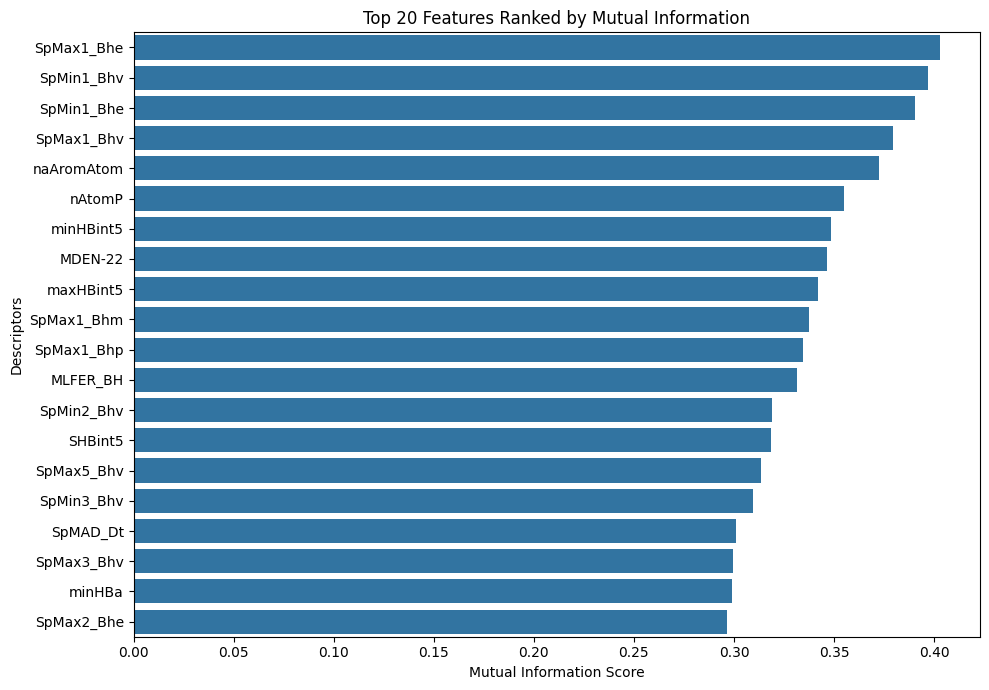

In [ ]:
# ==========================================================
# Top 20 Most Informative Features
# ==========================================================

plt.figure(figsize=(10,7))

sns.barplot(
    data=mi_df.head(20),
    x="MI_Score",
    y="Feature"
)

plt.title("Top 20 Features Ranked by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Descriptors")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Summary of Mutual Information Scores
# ==========================================================

print(mi_df["MI_Score"].describe())

print("\nDescriptors with MI > 0")
print((mi_df["MI_Score"] > 0).sum())

print("\nDescriptors with MI > 0.01")
print((mi_df["MI_Score"] > 0.01).sum())

print("\nDescriptors with MI > 0.02")
print((mi_df["MI_Score"] > 0.02).sum())

print("\nDescriptors with MI > 0.05")
print((mi_df["MI_Score"] > 0.05).sum())

count    968.000000
mean       0.095945
std        0.082916
min        0.000000
25%        0.028514
50%        0.076616
75%        0.138326
max        0.402770
Name: MI_Score, dtype: float64

Descriptors with MI > 0
937

Descriptors with MI > 0.01
846

Descriptors with MI > 0.02
768

Descriptors with MI > 0.05
617


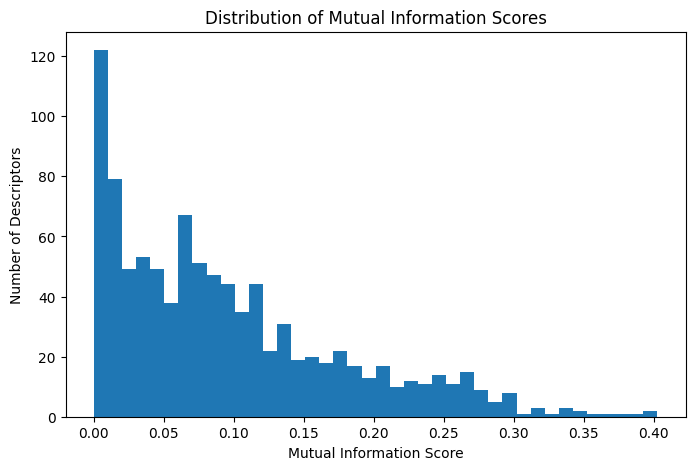

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(mi_df["MI_Score"], bins=40)

plt.xlabel("Mutual Information Score")
plt.ylabel("Number of Descriptors")
plt.title("Distribution of Mutual Information Scores")

plt.show()

In [ ]:
# ==========================================================
# Select Top 300 Features
# ==========================================================

TOP_N = 300

selected_features = mi_df.head(TOP_N)["Feature"].tolist()

X_train_mi = X_train[selected_features]
X_test_mi = X_test[selected_features]

print("Training set:", X_train_mi.shape)
print("Testing set :", X_test_mi.shape)

Training set: (2665, 300)
Testing set : (667, 300)


In [ ]:
# ==========================================================
# Save MI Ranking
# ==========================================================

mi_df.to_csv(
    "Mutual_Information_Feature_Ranking.csv",
    index=False
)

print("Mutual information ranking saved successfully!")

Mutual information ranking saved successfully!


In [ ]:
# ==========================================================
# Import Libraries for RFE
# ==========================================================

from xgboost import XGBRegressor

from sklearn.feature_selection import RFE

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================================
# Base XGBoost Model
# ==========================================================

xgb_base = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

print(xgb_base)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)


In [ ]:
# ==========================================================
# Number of Features to Evaluate
# ==========================================================

feature_numbers = [20, 30, 40, 50, 75, 100]

print(feature_numbers)

[20, 30, 40, 50, 75, 100]


In [ ]:
# ==========================================================
# Store Results
# ==========================================================

results = []

print(results)

[]


In [ ]:
# ==========================================================
# RFE + 5-Fold Cross Validation
# ==========================================================

from sklearn.model_selection import cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

selected_feature_sets = {}

for n_features in feature_numbers:

    print(f"\nEvaluating {n_features} features...")

    # -----------------------------
    # RFE
    # -----------------------------
    rfe = RFE(
        estimator=xgb_base,
        n_features_to_select=n_features,
        step=10
    )

    X_train_rfe = rfe.fit_transform(
        X_train_mi,
        y_train
    )

    # Save selected feature names
    selected_features = X_train_mi.columns[rfe.support_]
    selected_feature_sets[n_features] = selected_features

    # -----------------------------
    # Cross Validation
    # -----------------------------
    scores = cross_validate(
        estimator=xgb_base,
        X=X_train_rfe,
        y=y_train,
        cv=cv,
        scoring={
            "R2":"r2",
            "RMSE":"neg_root_mean_squared_error",
            "MAE":"neg_mean_absolute_error",
            "MSE":"neg_mean_squared_error"
        },
        n_jobs=-1
    )

    results.append({
        "Features": n_features,
        "CV_R2": scores["test_R2"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_MSE": -scores["test_MSE"].mean()
    })

print("\nFinished!")


Evaluating 20 features...

Evaluating 30 features...

Evaluating 40 features...

Evaluating 50 features...

Evaluating 75 features...

Evaluating 100 features...

Finished!


In [ ]:
# ==========================================================
# RFE Performance Summary
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV_R2",
    ascending=False
).reset_index(drop=True)

results_df

,Features,CV_R2,CV_RMSE,CV_MAE,CV_MSE
0,75,0.666083,0.637081,0.459800,0.406565
1,30,0.665247,0.637637,0.472805,0.407191
2,100,0.664813,0.638061,0.457729,0.408081
3,50,0.663286,0.638968,0.467162,0.409107
4,40,0.663145,0.639236,0.469154,0.409813
5,20,0.647250,0.654542,0.479598,0.428997


In [ ]:
# ==========================================================
# Save Results
# ==========================================================

results_df.to_csv(
    "RFE_Feature_Selection_Results.csv",
    index=False
)

print(results_df)

   Features     CV_R2   CV_RMSE    CV_MAE    CV_MSE
0        75  0.666083  0.637081  0.459800  0.406565
1        30  0.665247  0.637637  0.472805  0.407191
2       100  0.664813  0.638061  0.457729  0.408081
3        50  0.663286  0.638968  0.467162  0.409107
4        40  0.663145  0.639236  0.469154  0.409813
5        20  0.647250  0.654542  0.479598  0.428997


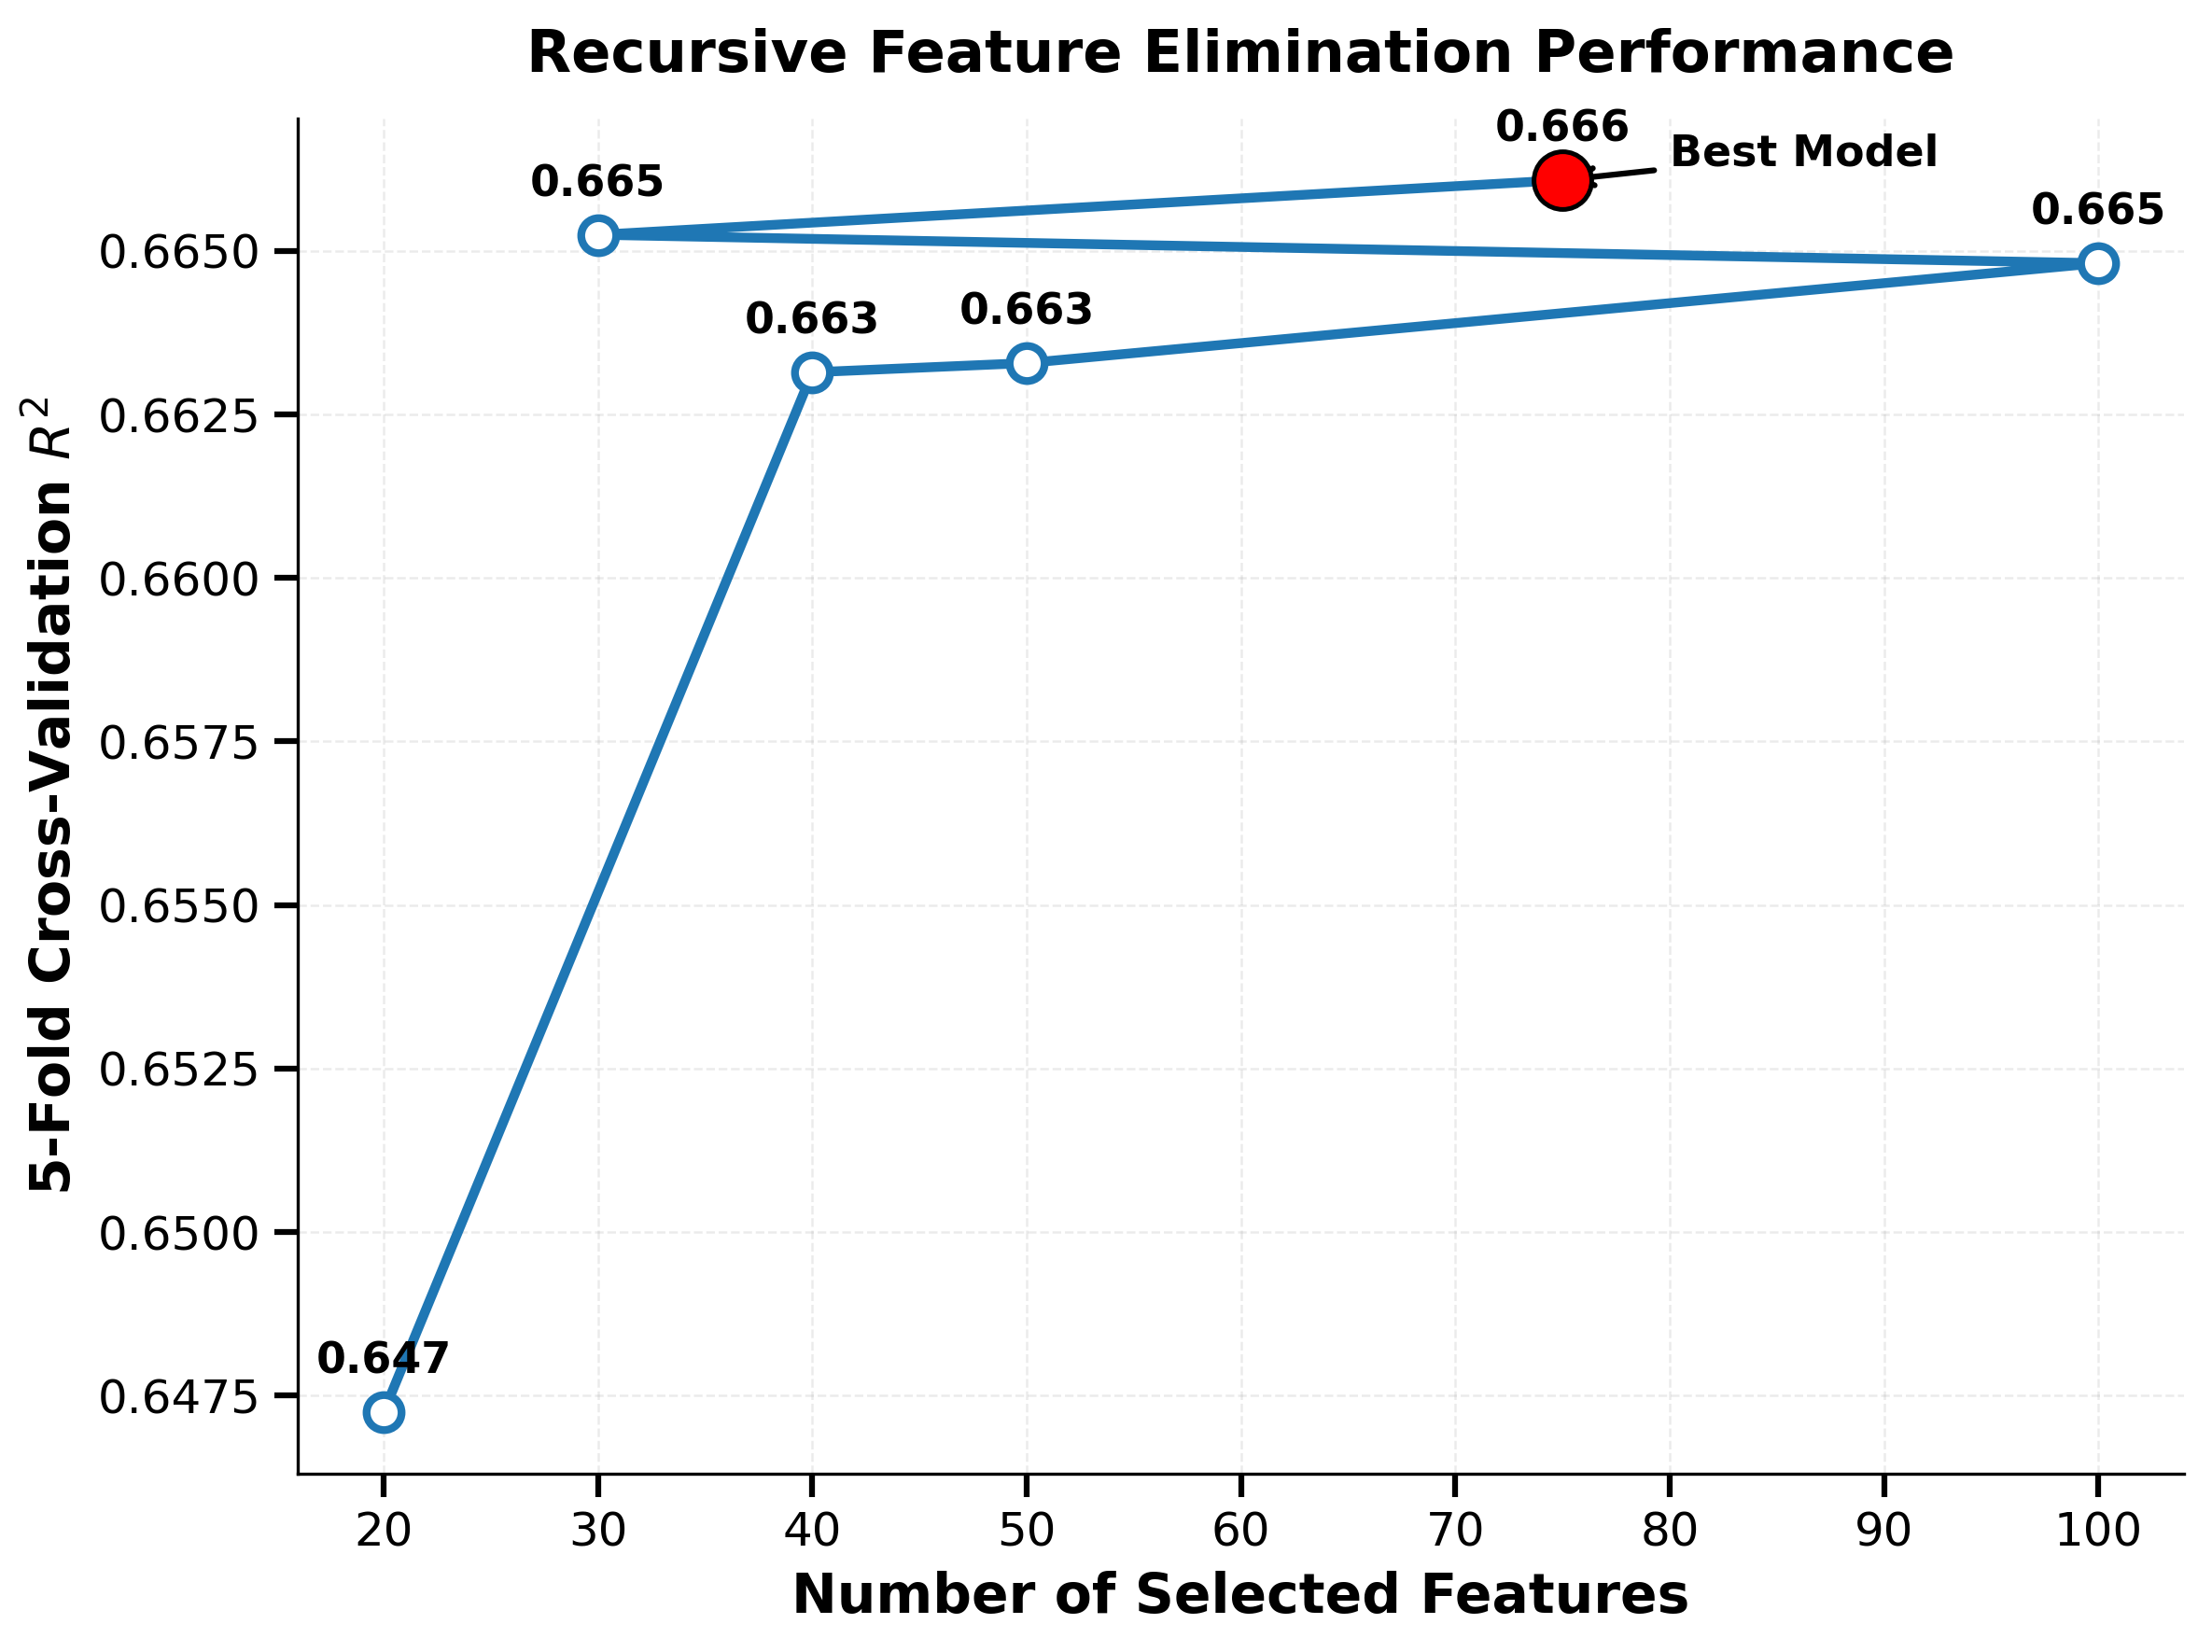

In [ ]:
# ==========================================================
# Publication-quality Figure
# Recursive Feature Elimination Performance
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Global font settings
# ----------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# ----------------------------------------------------------
# Line Plot
# ----------------------------------------------------------
ax.plot(
    results_df["Features"],
    results_df["CV_R2"],
    color="#1f77b4",
    linewidth=2.5,
    marker="o",
    markersize=9,
    markerfacecolor="white",
    markeredgecolor="#1f77b4",
    markeredgewidth=2
)

# ----------------------------------------------------------
# Highlight Best Model
# ----------------------------------------------------------
best_idx = results_df["CV_R2"].idxmax()

best_x = results_df.loc[best_idx, "Features"]
best_y = results_df.loc[best_idx, "CV_R2"]

ax.scatter(
    best_x,
    best_y,
    s=220,
    color="red",
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)

# ----------------------------------------------------------
# Add CV R² Values
# ----------------------------------------------------------
for x, y in zip(results_df["Features"], results_df["CV_R2"]):

    ax.text(
        x,
        y + 0.00045,
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ----------------------------------------------------------
# Best Model Annotation
# ----------------------------------------------------------
ax.annotate(
    "Best Model",
    xy=(best_x, best_y),
    xytext=(80, 0.6663),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5,
        color="black"
    )
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------
ax.set_xlabel(
    "Number of Selected Features",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "5-Fold Cross-Validation $R^2$",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Recursive Feature Elimination Performance",
    fontsize=15,
    fontweight="bold",
    pad=12
)

# ----------------------------------------------------------
# Tick Parameters
# ----------------------------------------------------------
ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    width=1.5,
    length=6
)

# ----------------------------------------------------------
# Grid
# ----------------------------------------------------------
ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)

# ----------------------------------------------------------
# Remove Top and Right Border
# ----------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ----------------------------------------------------------
# Tight Layout
# ----------------------------------------------------------
plt.tight_layout()

# ==========================================================
# Save Figure
# ==========================================================

plt.savefig(
    "Figure_RFE_Performance.tiff",
    dpi=600,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.savefig(
    "Figure_RFE_Performance.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure_RFE_Performance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# Extract Best Feature Set
# ==========================================================

best_n_features = 75

best_features = list(selected_feature_sets[best_n_features])

X_train_final = X_train_mi[best_features]

X_test_final = X_test_mi[best_features]

print("Training shape :", X_train_final.shape)
print("Testing shape  :", X_test_final.shape)

Training shape : (2665, 75)
Testing shape  : (667, 75)


In [ ]:
# ==========================================================
# Save Selected Features
# ==========================================================

selected_features_df = pd.DataFrame({
    "Selected_Features": best_features
})

selected_features_df.to_csv(
    "Selected_75_Features.csv",
    index=False
)

selected_features_df.head()

,Selected_Features
0,MLFER_BH
1,SHBint5
2,SpMin3_Bhv
3,SpMin3_Bhm
4,MDEN-23


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 9.9 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import optuna

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor

print("Optuna Version :", optuna.__version__)

Optuna Version : 4.9.0


In [ ]:
# ==========================================================
# Optuna Objective Function
# ==========================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {

        "objective": "reg:squarederror",

        "random_state": 42,

        "n_jobs": -1,

        # ----------------------------
        # Hyperparameters to optimize
        # ----------------------------

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            800
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.5,
            10
        )

    }

    model = XGBRegressor(**params)

    scores = cross_val_score(

        estimator=model,

        X=X_train_final,

        y=y_train,

        cv=cv,

        scoring="r2",

        n_jobs=-1

    )

    return scores.mean()

In [ ]:
# ==========================================================
# Run Optuna Optimization
# ==========================================================

import optuna

# Reproducibility
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = optuna.samplers.TPESampler(
    seed=42
)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=5
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="HER2_XGBoost_QSAR"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print("="*60)
print("Optimization Finished")
print("="*60)

print(f"Best CV R² : {study.best_value:.4f}")

print("\nBest Parameters:\n")

for key, value in study.best_params.items():
    print(f"{key:20s}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

Optimization Finished
Best CV R² : 0.7008

Best Parameters:

n_estimators        : 501
learning_rate       : 0.06111430124257152
max_depth           : 6
min_child_weight    : 5
subsample           : 0.9767375765950344
colsample_bytree    : 0.7713759657450407
gamma               : 0.022361181460870738
reg_alpha           : 0.502270699296059
reg_lambda          : 1.9207048050153384


In [ ]:
# ==========================================================
# Train Final XGBoost Model
# ==========================================================

best_model = XGBRegressor(
    **study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train_final,
    y_train
)

print("Final model trained successfully!")

Final model trained successfully!


In [ ]:
# ==========================================================
# Predictions
# ==========================================================

train_pred = best_model.predict(X_train_final)

test_pred = best_model.predict(X_test_final)

print("Prediction completed!")

Prediction completed!


In [ ]:
# ==========================================================
# Performance Evaluation
# ==========================================================

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

def regression_metrics(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    return r2, rmse, mae, mse


train_r2, train_rmse, train_mae, train_mse = regression_metrics(
    y_train,
    train_pred
)

test_r2, test_rmse, test_mae, test_mse = regression_metrics(
    y_test,
    test_pred
)

performance = pd.DataFrame({

    "Dataset":[
        "Training",
        "Testing"
    ],

    "R²":[
        train_r2,
        test_r2
    ],

    "RMSE":[
        train_rmse,
        test_rmse
    ],

    "MAE":[
        train_mae,
        test_mae
    ],

    "MSE":[
        train_mse,
        test_mse
    ]

})

performance

,Dataset,R²,RMSE,MAE,MSE
0,Training,0.980475,0.154318,0.106365,0.023814
1,Testing,0.683793,0.576541,0.418725,0.332399


In [ ]:
performance.to_csv(
    "Final_Model_Performance.csv",
    index=False
)

performance

,Dataset,R²,RMSE,MAE,MSE
0,Training,0.980475,0.154318,0.106365,0.023814
1,Testing,0.683793,0.576541,0.418725,0.332399


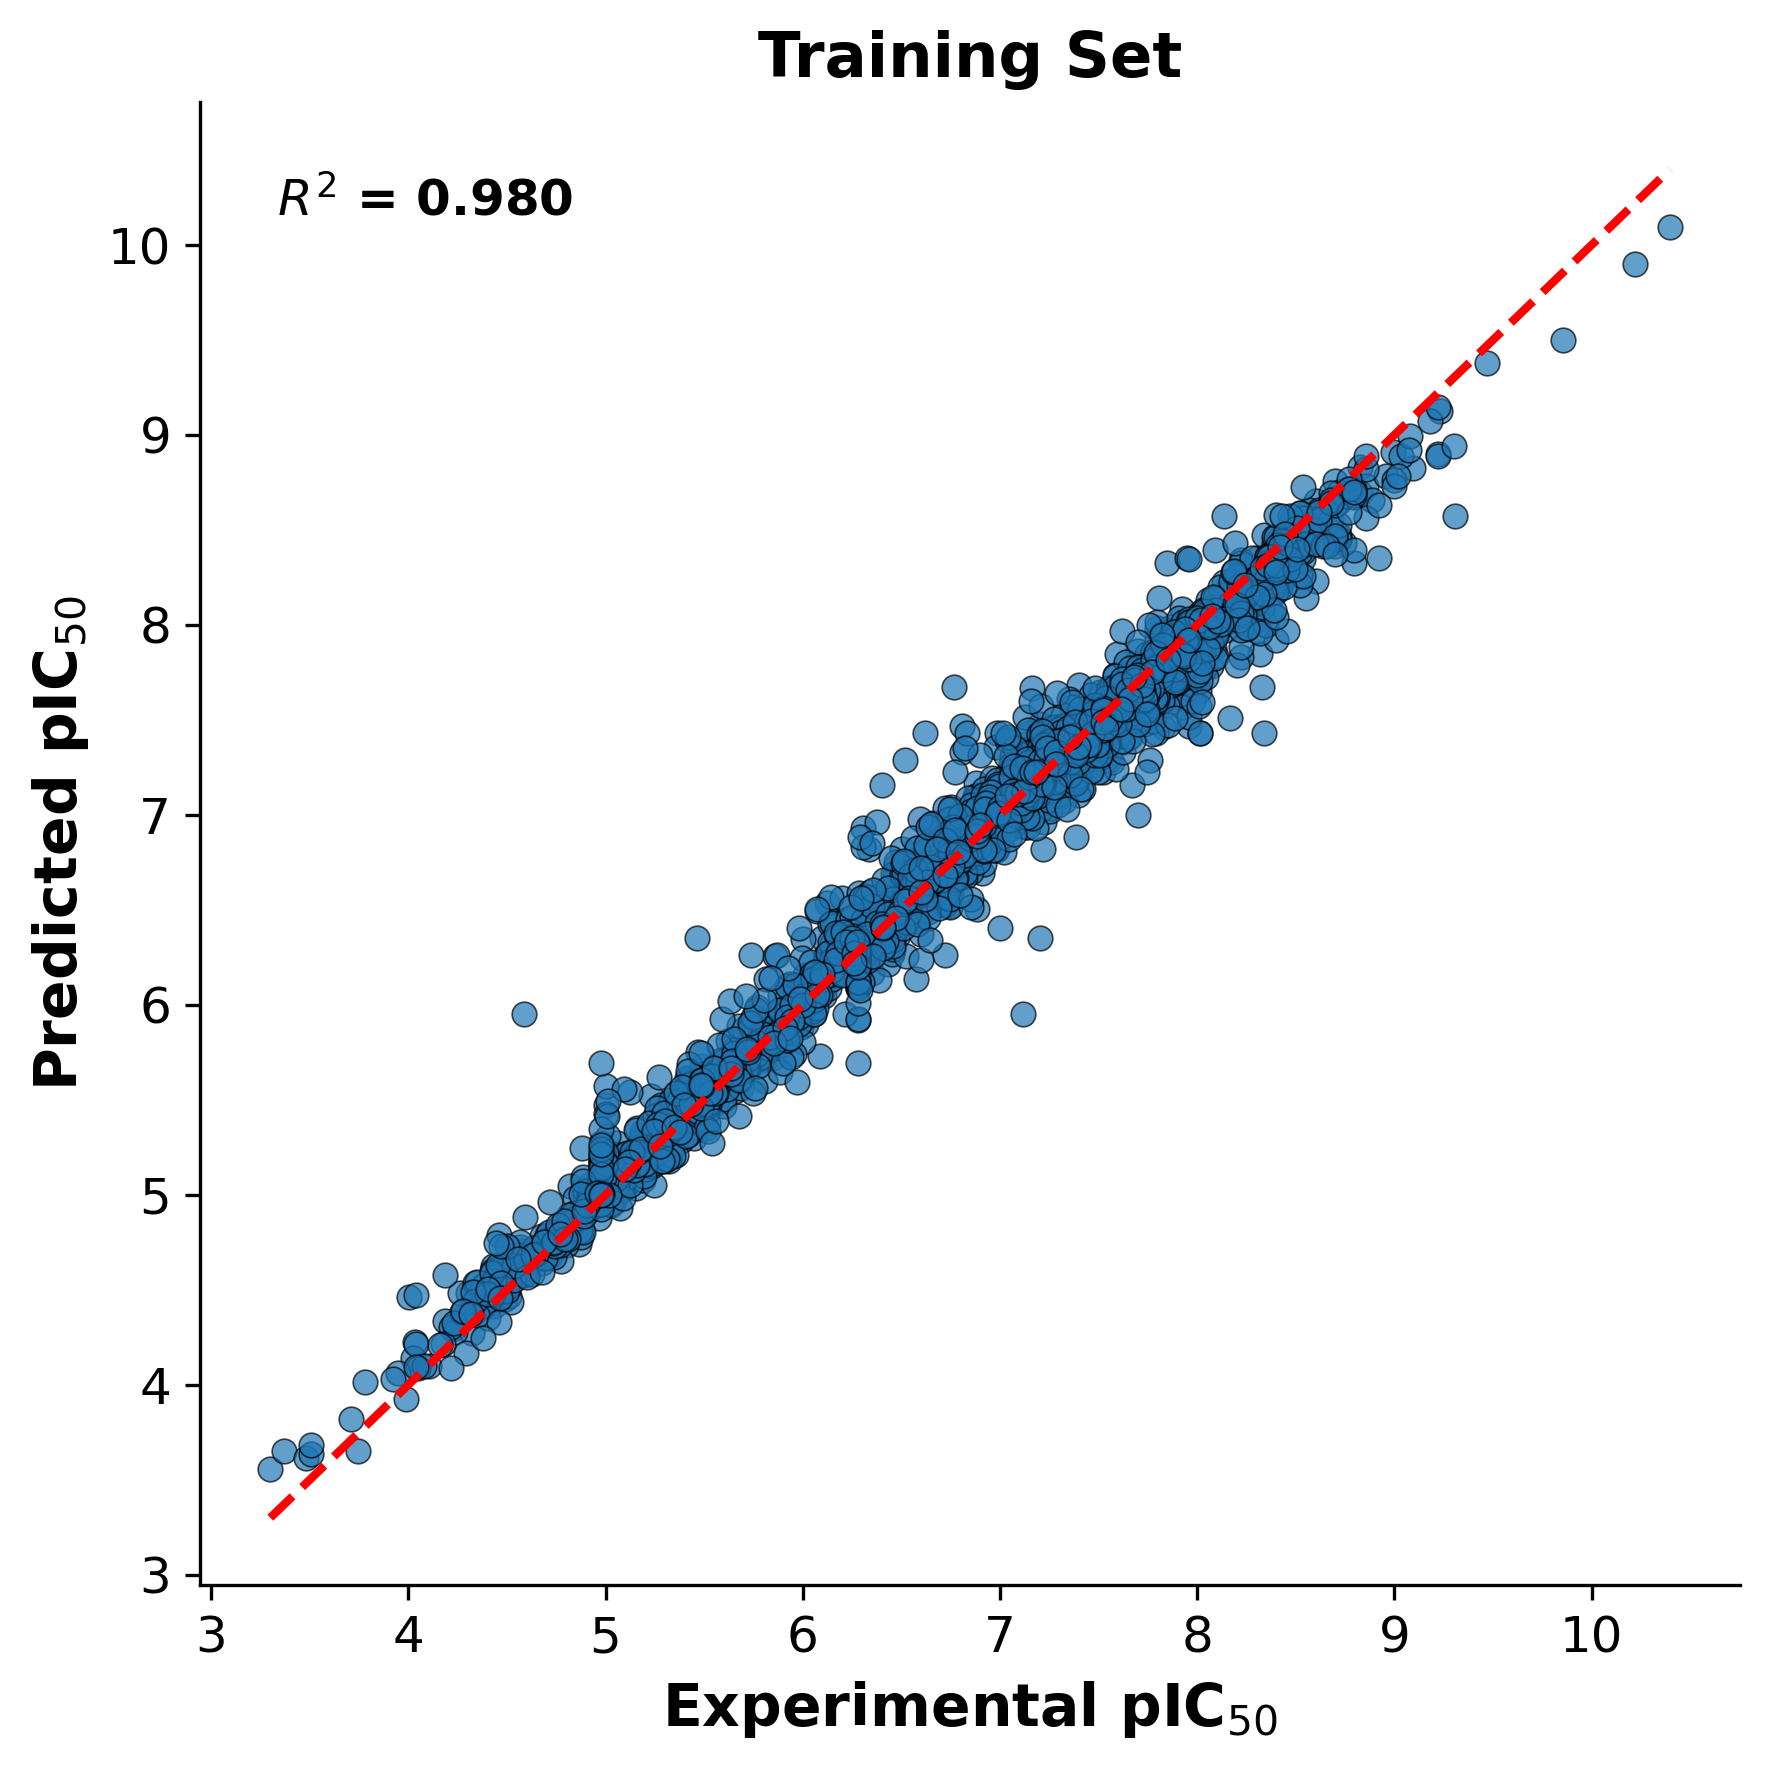

In [ ]:
# ==========================================================
# Training Set: Observed vs Predicted
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6,6), dpi=300)

# Scatter
ax.scatter(
    y_train,
    train_pred,
    s=35,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.4
)

# Identity line
min_val = min(y_train.min(), train_pred.min())
max_val = max(y_train.max(), train_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

# Metrics
r2 = r2_score(y_train, train_pred)

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top"
)

# Labels
ax.set_xlabel(
    "Experimental pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Predicted pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Training Set",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Training_Observed_vs_Predicted.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Training_Observed_vs_Predicted.pdf",
    bbox_inches="tight"
)

plt.show()

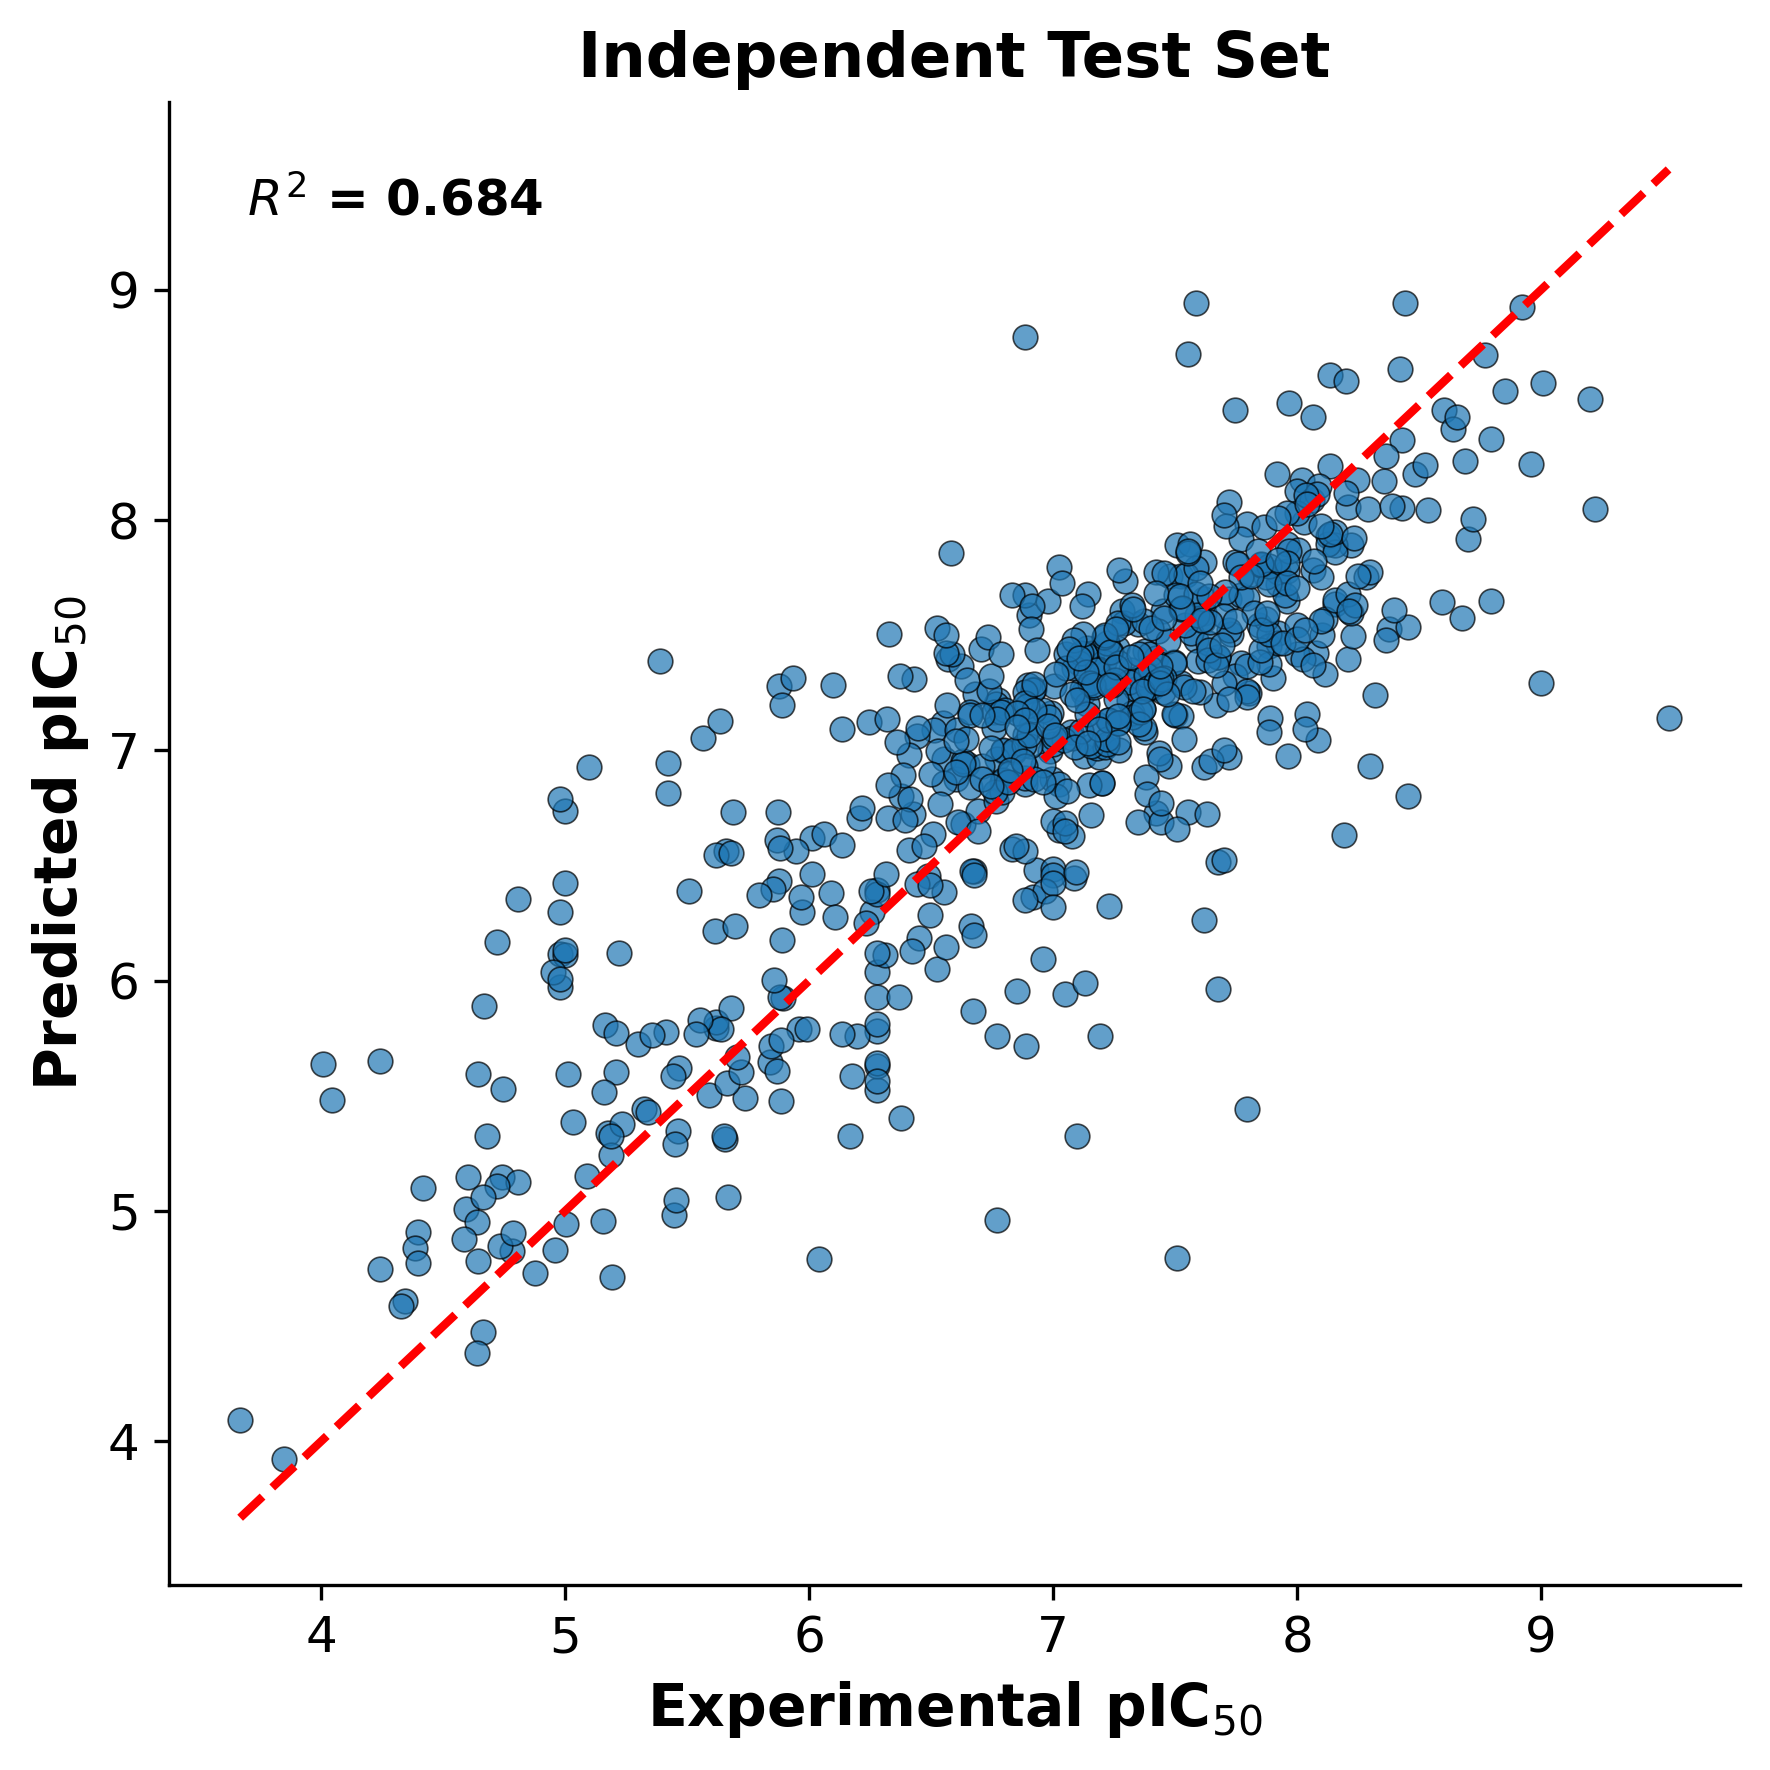

In [ ]:
# ==========================================================
# Test Set: Observed vs Predicted
# ==========================================================

fig, ax = plt.subplots(figsize=(6,6), dpi=300)

ax.scatter(
    y_test,
    test_pred,
    s=35,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.4
)

min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

r2 = r2_score(y_test, test_pred)

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top"
)

ax.set_xlabel(
    "Experimental pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Predicted pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Independent Test Set",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Testing_Observed_vs_Predicted.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Testing_Observed_vs_Predicted.pdf",
    bbox_inches="tight"
)

plt.show()

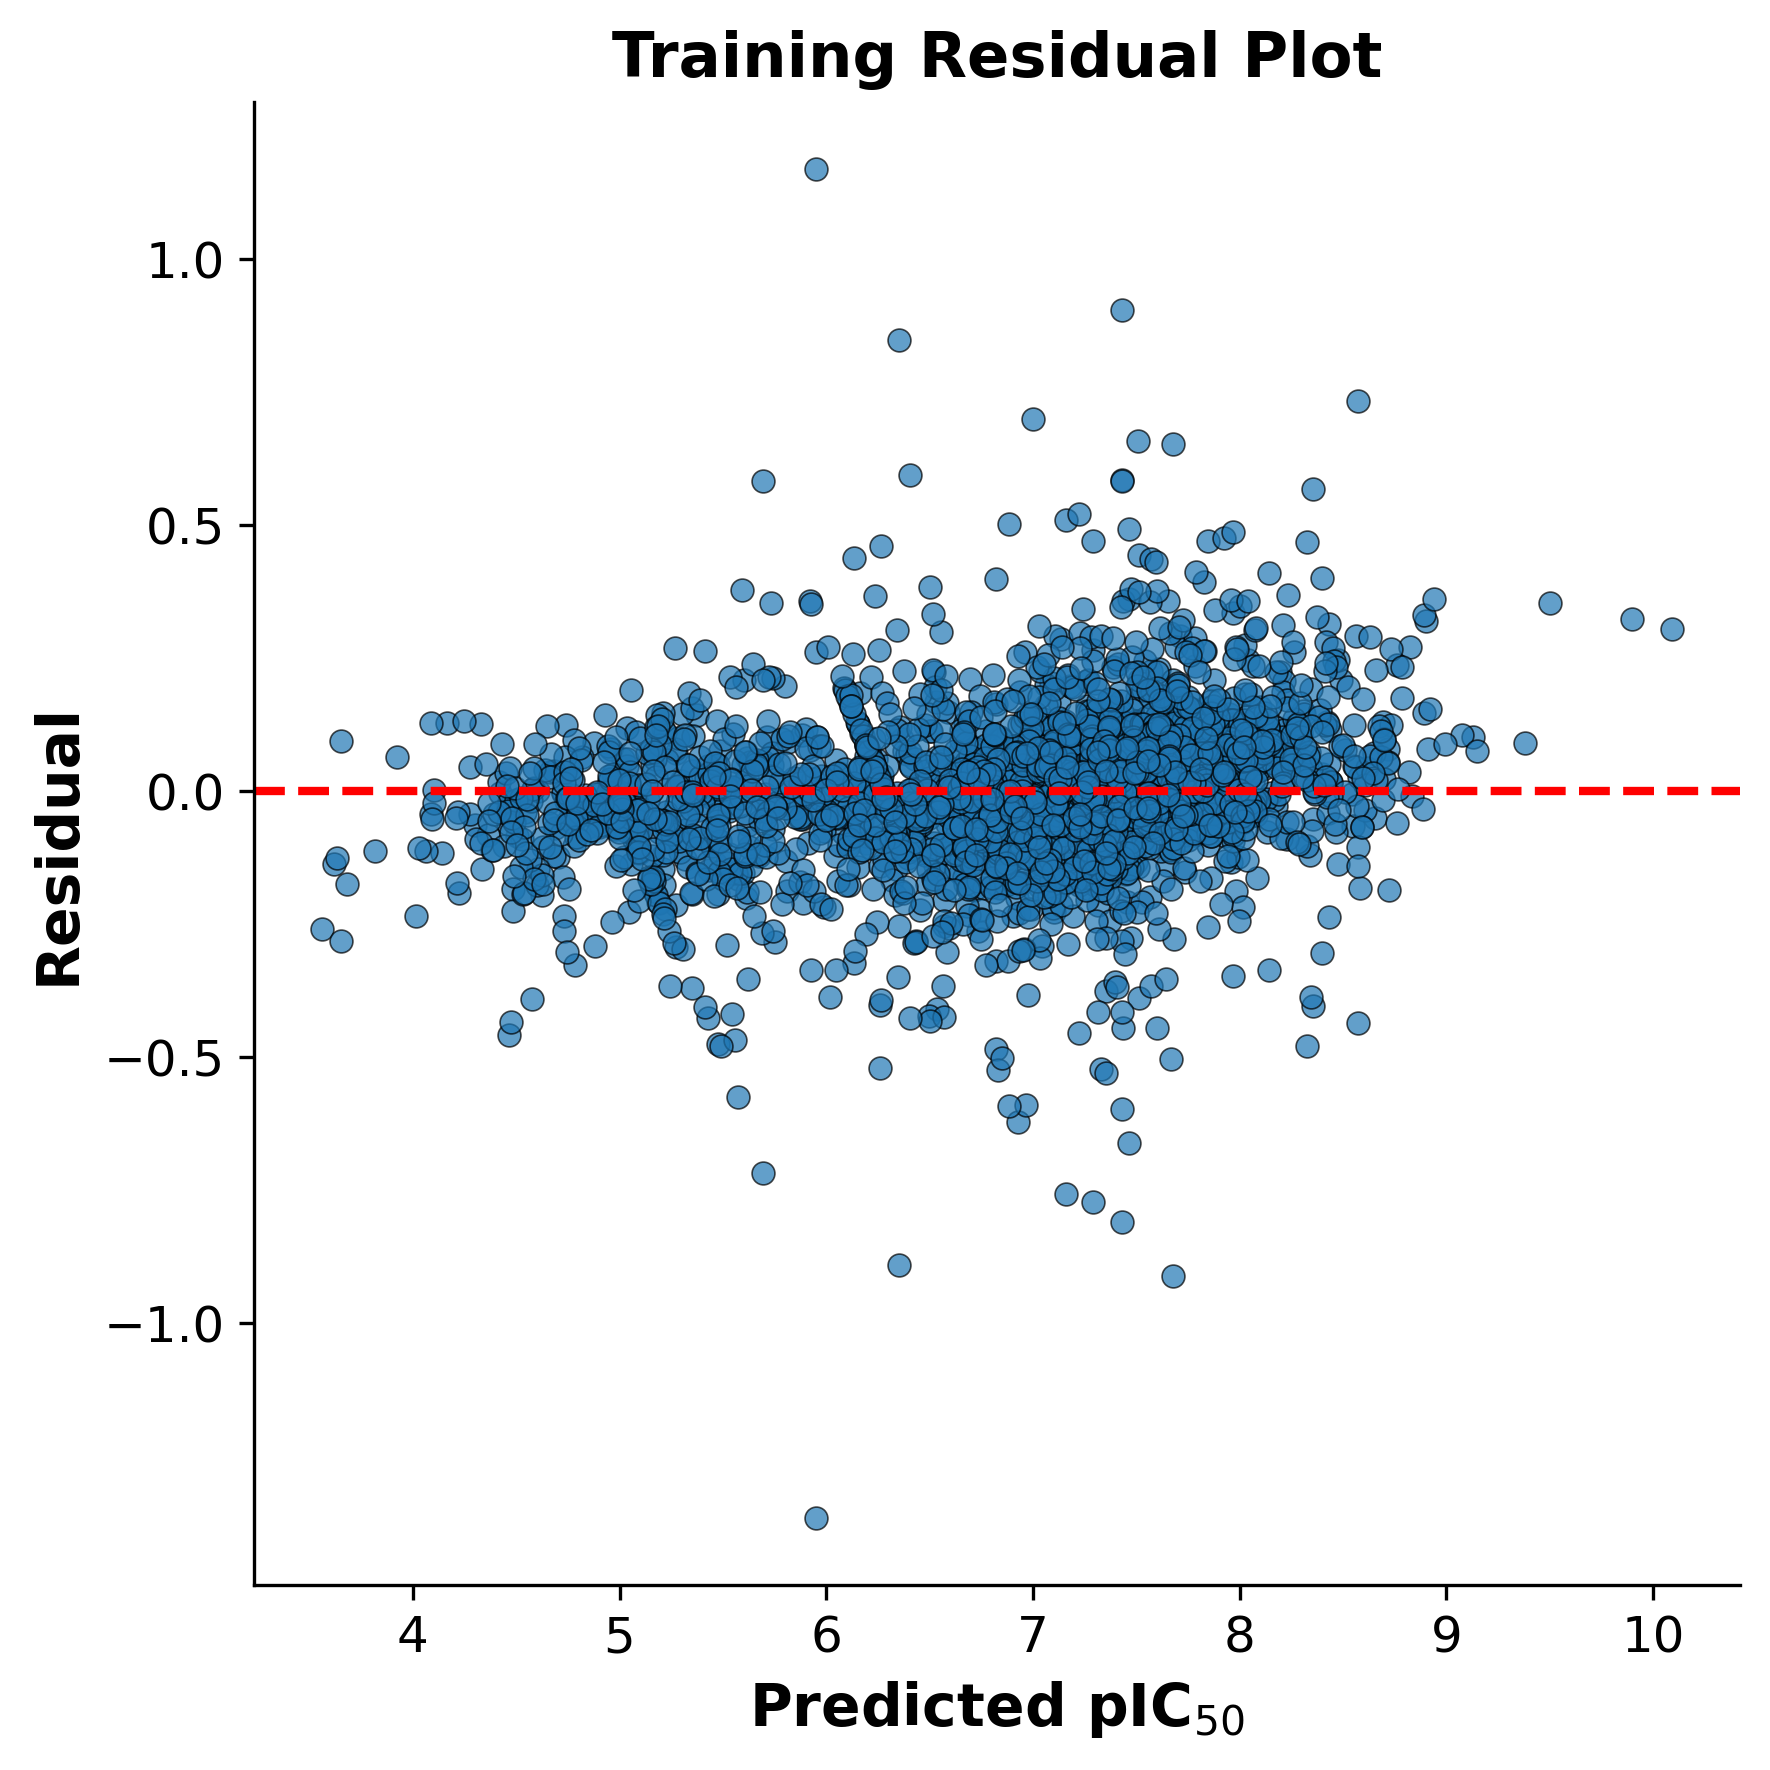

In [ ]:
# ==========================================================
# Training Residual Plot
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

train_residuals = y_train - train_pred

fig, ax = plt.subplots(figsize=(6,6), dpi=300)

ax.scatter(
    train_pred,
    train_residuals,
    s=30,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.4
)

ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.set_xlabel(
    "Predicted pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Residual",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Training Residual Plot",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Training_Residual_Plot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

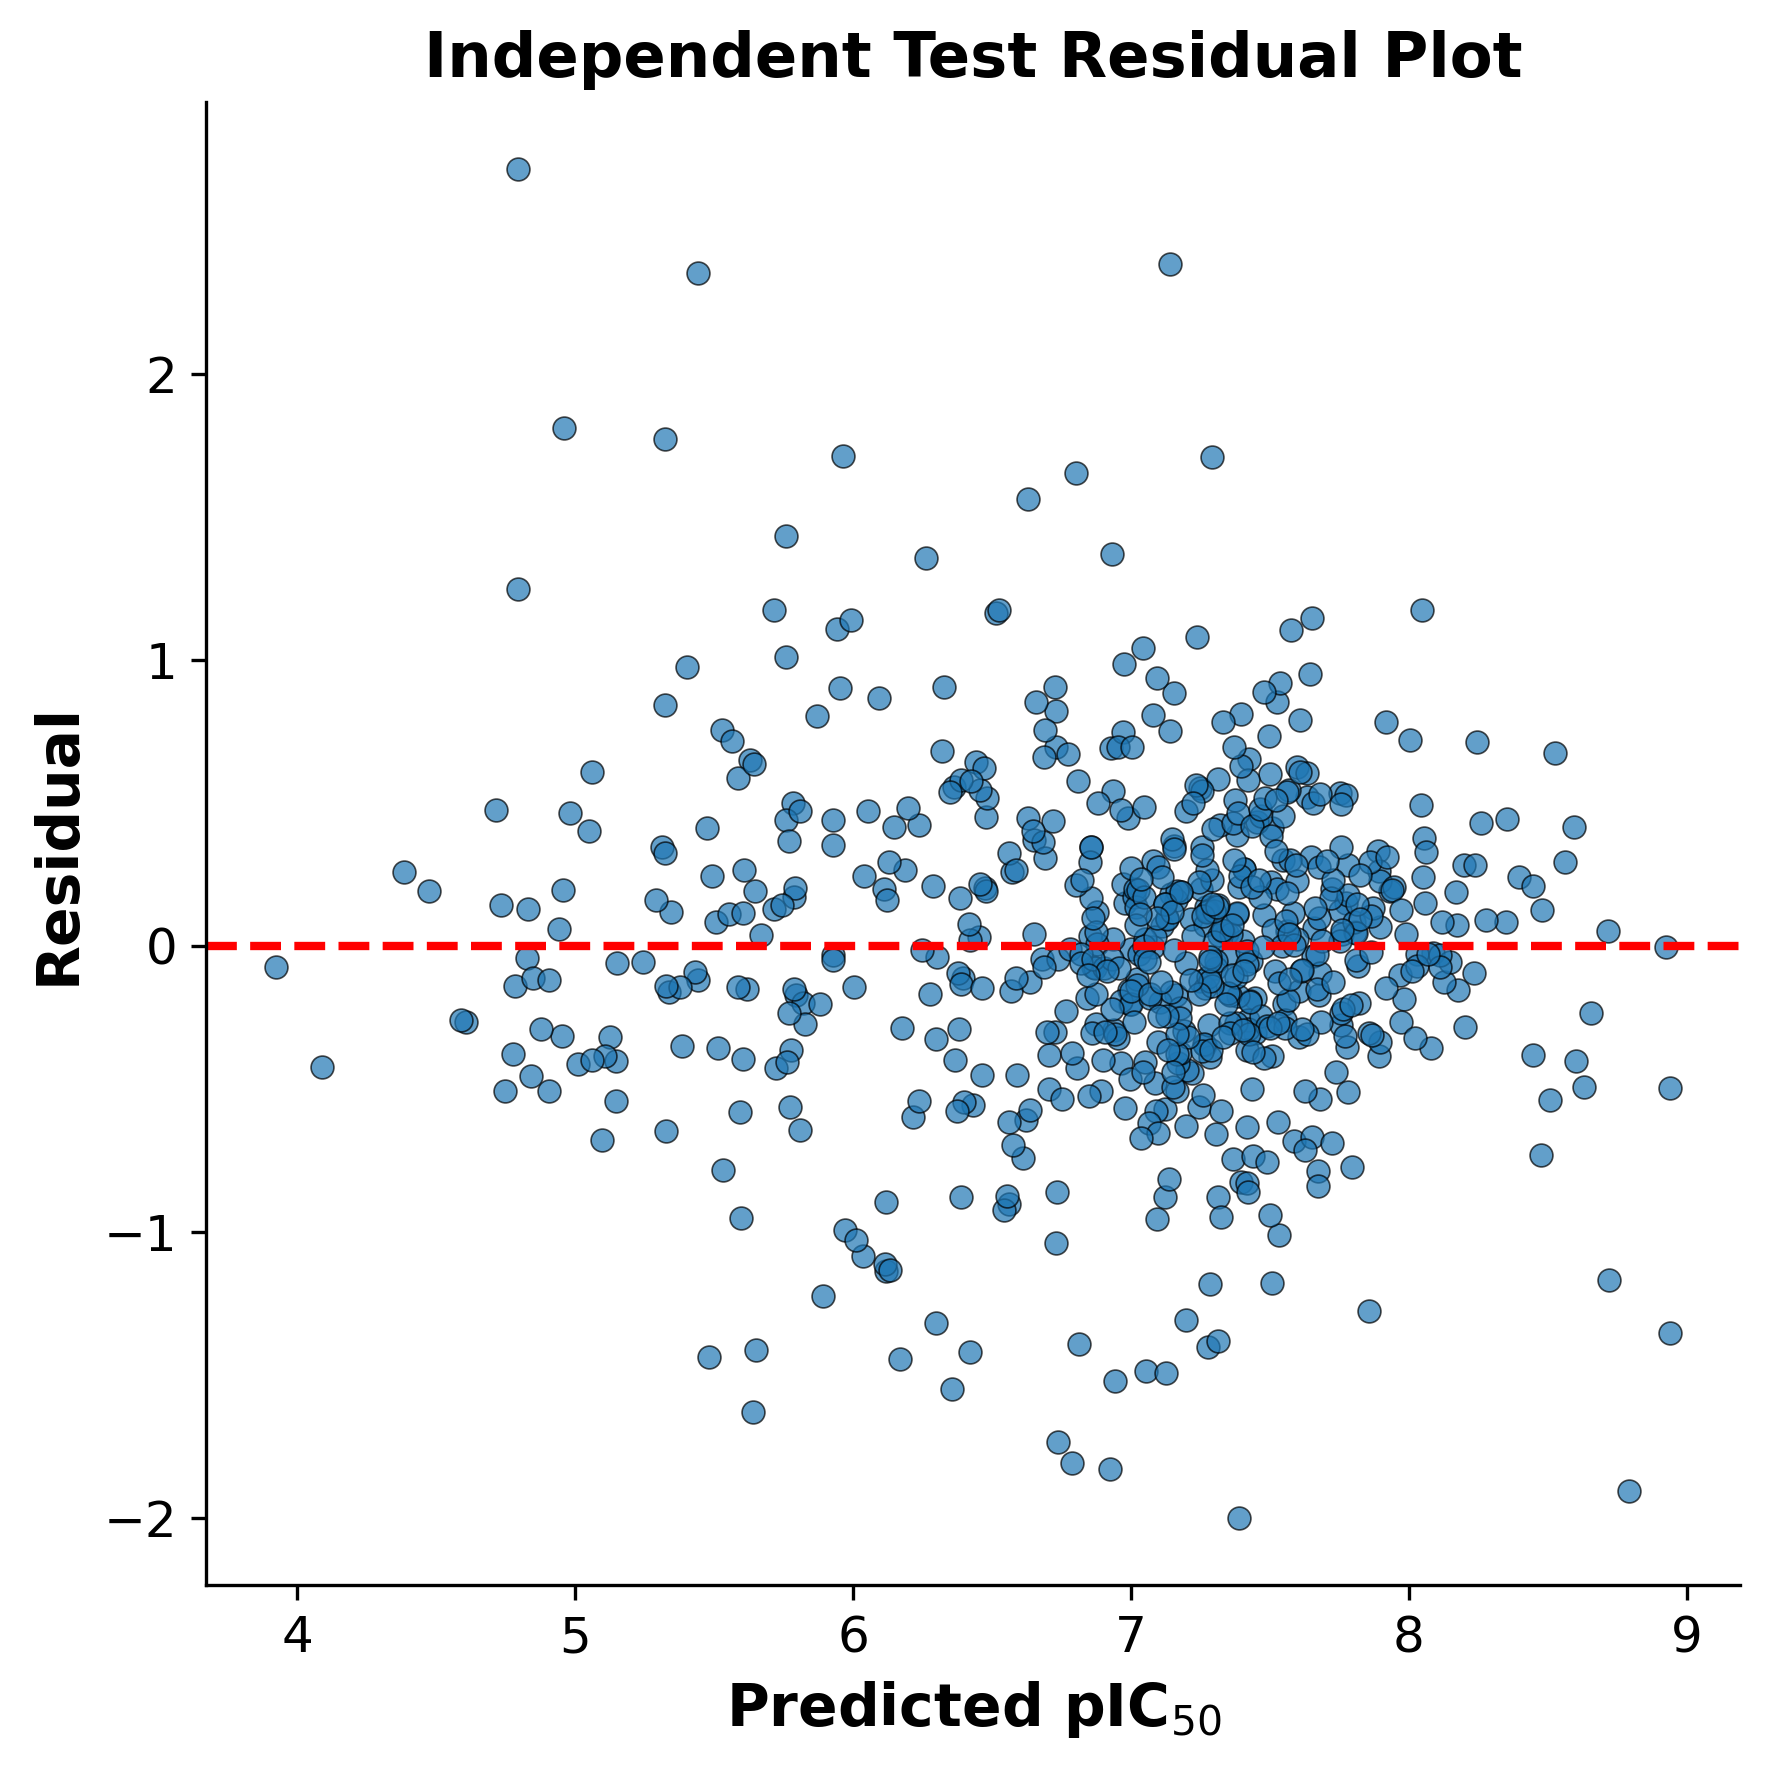

In [ ]:
# ==========================================================
# Test Residual Plot
# ==========================================================

test_residuals = y_test - test_pred

fig, ax = plt.subplots(figsize=(6,6), dpi=300)

ax.scatter(
    test_pred,
    test_residuals,
    s=30,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.4
)

ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.set_xlabel(
    "Predicted pIC$_{50}$",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Residual",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Independent Test Residual Plot",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Testing_Residual_Plot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# XGBoost Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,PubchemFP593,0.678297
1,MLFER_BH,0.041613
2,n6HeteroRing,0.033243
3,minHBint2,0.019291
4,maxHother,0.012162
5,minsCl,0.011734
6,nHaaCH,0.011430
7,maxaasC,0.010775
8,nHBint5,0.010645
9,SaaaC,0.006145


In [ ]:
feature_importance.to_csv(
    "XGBoost_Feature_Importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


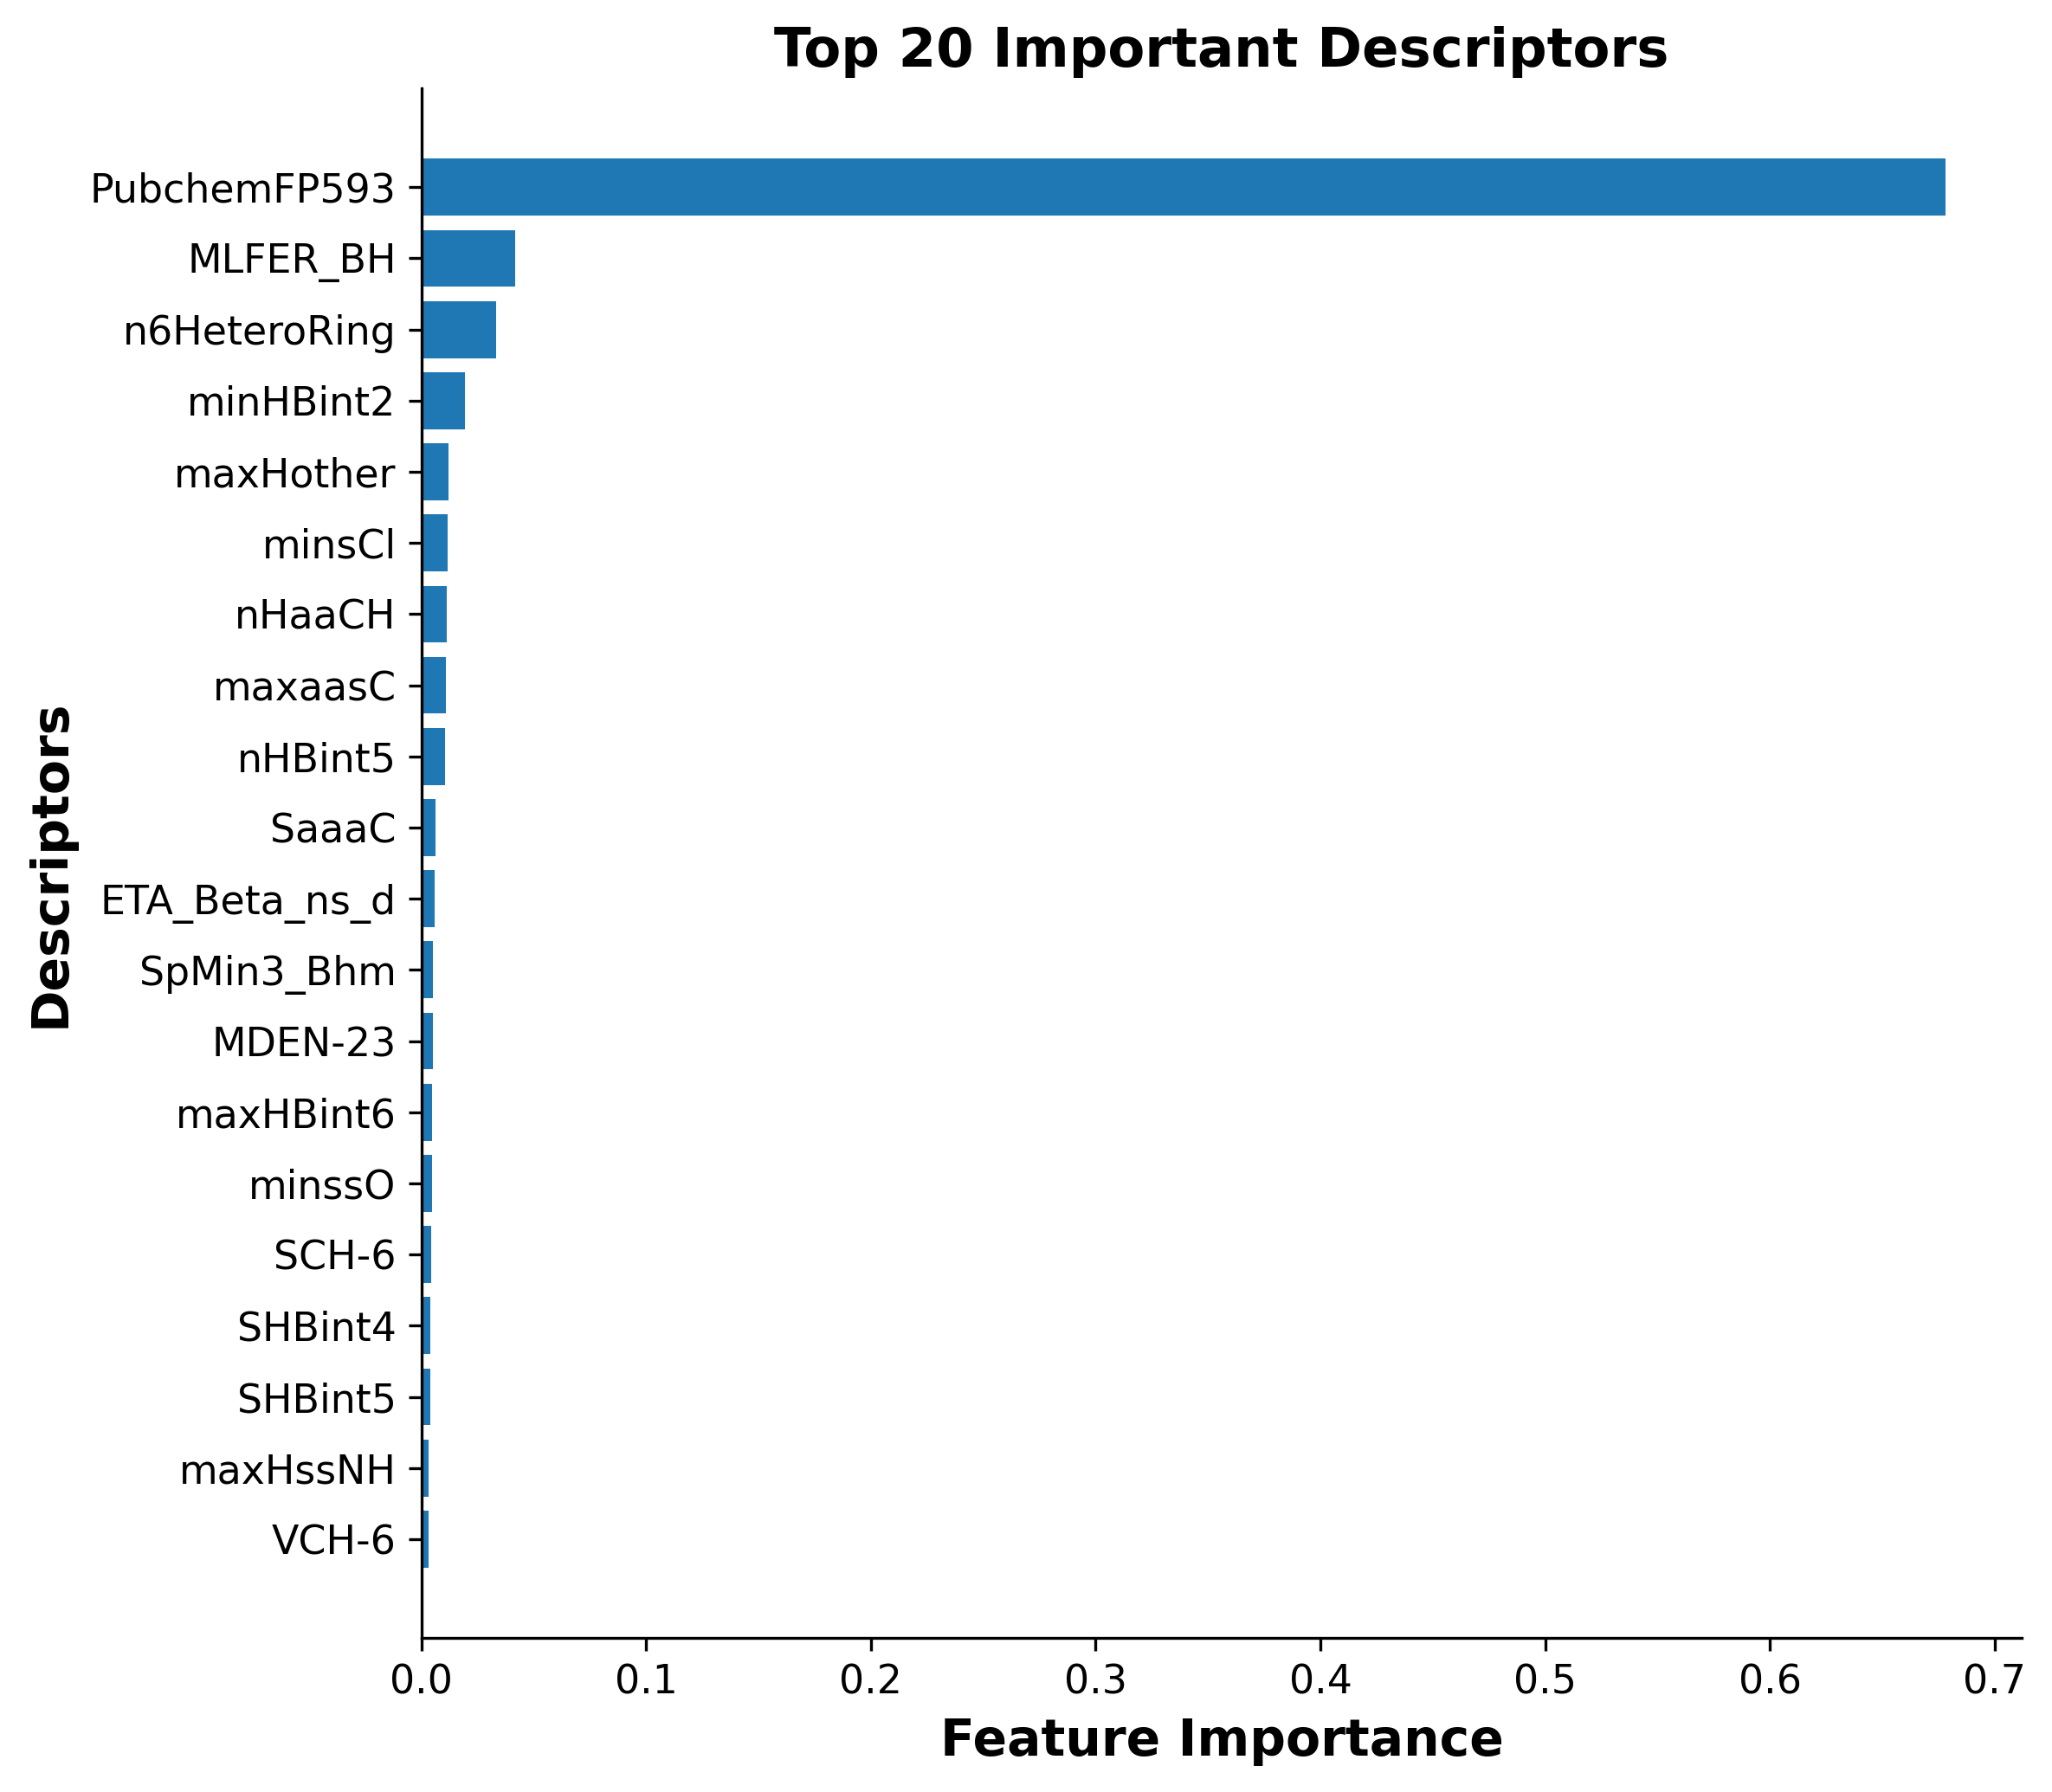

In [ ]:
# ==========================================================
# Top 20 Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

top20 = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(8,7), dpi=300)

ax.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Descriptors",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Top 20 Important Descriptors",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Feature_Importance.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Feature_Importance.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install shap -q

In [ ]:
# ==========================================================
# Import SHAP
# ==========================================================

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# ==========================================================
# Calculate SHAP Values
# ==========================================================

import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_train_final)

print("SHAP values calculated successfully!")
print(shap_values.shape)

SHAP values calculated successfully!
(2665, 75)


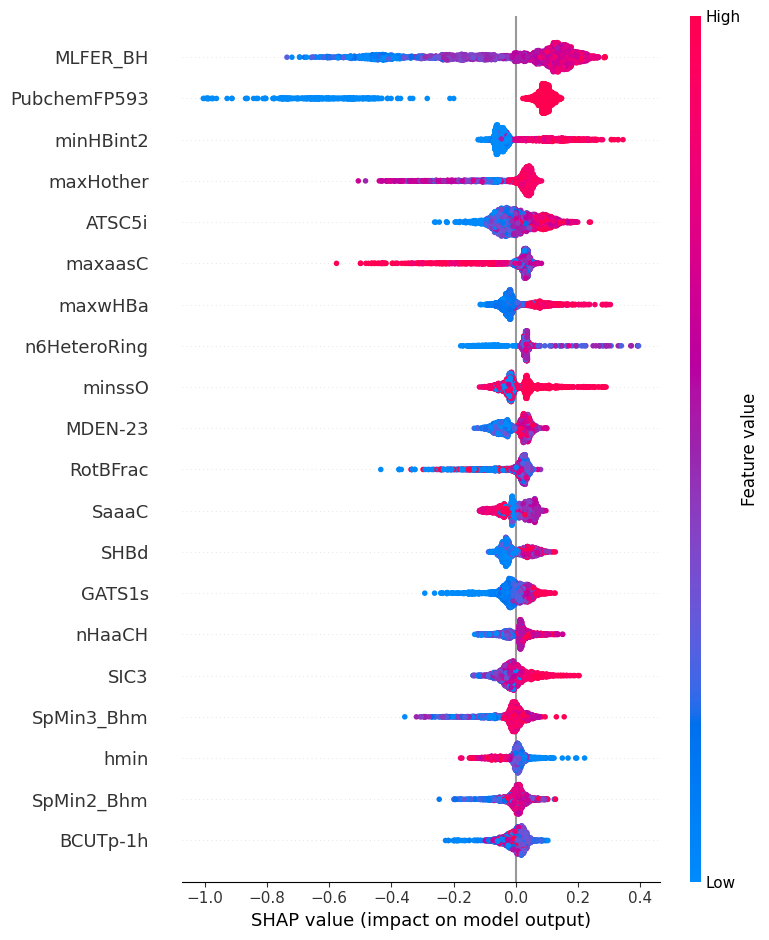

In [ ]:
# ==========================================================
# SHAP Summary Plot
# ==========================================================

plt.rcParams["font.family"] = "Times New Roman"

shap.summary_plot(
    shap_values,
    X_train_final,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "SHAP_Summary.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "SHAP_Summary.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

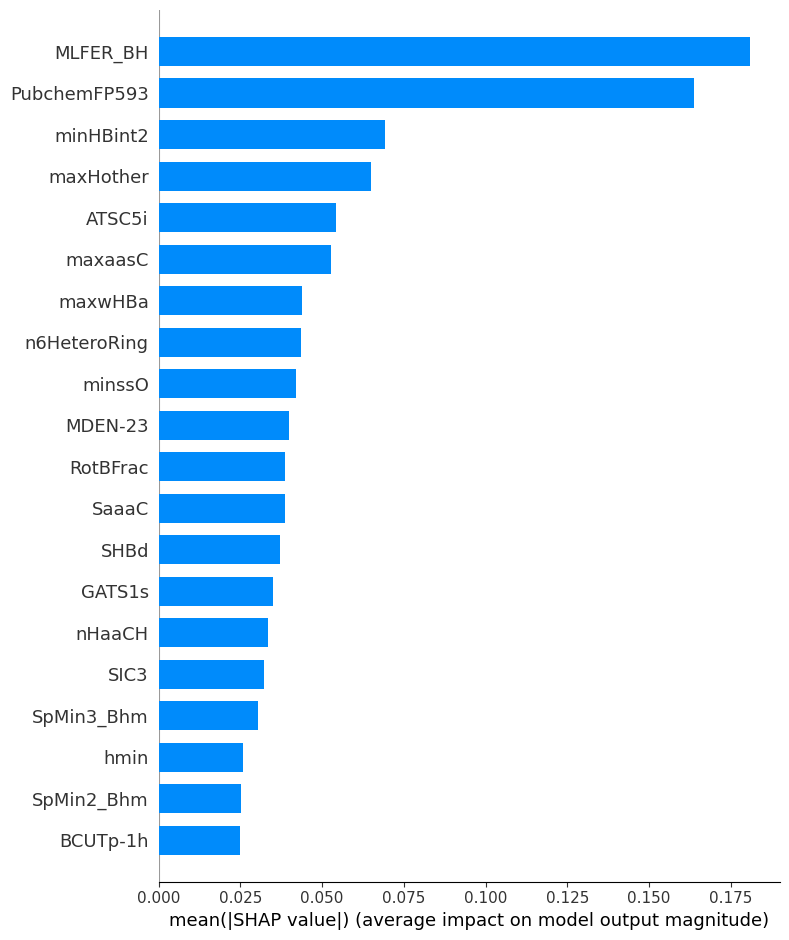

In [ ]:
# ==========================================================
# SHAP Bar Plot
# ==========================================================

plt.rcParams["font.family"] = "Times New Roman"

shap.summary_plot(
    shap_values,
    X_train_final,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "SHAP_Bar.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "SHAP_Bar.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# Import Libraries for Y-Randomization
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================================
# Number of Randomizations
# ==========================================================

n_randomizations = 30

random_r2 = []

print(f"Total randomizations: {n_randomizations}")

Total randomizations: 30


In [ ]:
# ==========================================================
# Perform Y-Randomization
# ==========================================================

for i in range(n_randomizations):

    # Shuffle target values
    y_random = shuffle(
        y_train,
        random_state=i
    )

    # 5-fold Cross Validation
    scores = cross_val_score(
        estimator=best_model,
        X=X_train_final,
        y=y_random,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    random_r2.append(scores.mean())

    print(
        f"Iteration {i+1:02d} | "
        f"Randomized CV R² = {scores.mean():.4f}"
    )

Iteration 01 | Randomized CV R² = -0.2577
Iteration 02 | Randomized CV R² = -0.2803
Iteration 03 | Randomized CV R² = -0.3131
Iteration 04 | Randomized CV R² = -0.2327
Iteration 05 | Randomized CV R² = -0.2685
Iteration 06 | Randomized CV R² = -0.2735
Iteration 07 | Randomized CV R² = -0.2611
Iteration 08 | Randomized CV R² = -0.2598
Iteration 09 | Randomized CV R² = -0.2711
Iteration 10 | Randomized CV R² = -0.2479
Iteration 11 | Randomized CV R² = -0.3019
Iteration 12 | Randomized CV R² = -0.2894
Iteration 13 | Randomized CV R² = -0.3492
Iteration 14 | Randomized CV R² = -0.2585
Iteration 15 | Randomized CV R² = -0.3182
Iteration 16 | Randomized CV R² = -0.2930
Iteration 17 | Randomized CV R² = -0.2454
Iteration 18 | Randomized CV R² = -0.3071
Iteration 19 | Randomized CV R² = -0.2620
Iteration 20 | Randomized CV R² = -0.2782
Iteration 21 | Randomized CV R² = -0.2800
Iteration 22 | Randomized CV R² = -0.2700
Iteration 23 | Randomized CV R² = -0.2385
Iteration 24 | Randomized CV R² = 

In [ ]:
# ==========================================================
# Summary Statistics
# ==========================================================

random_r2 = np.array(random_r2)

print("="*60)

print(f"Original CV R² : {study.best_value:.4f}")

print(f"Mean Random R² : {random_r2.mean():.4f}")

print(f"Maximum Random R² : {random_r2.max():.4f}")

print(f"Minimum Random R² : {random_r2.min():.4f}")

print("="*60)

Original CV R² : 0.7008
Mean Random R² : -0.2726
Maximum Random R² : -0.2240
Minimum Random R² : -0.3492


In [ ]:
# ==========================================================
# Save Y-Randomization Results
# ==========================================================

yrandom_df = pd.DataFrame({
    "Iteration": np.arange(1, n_randomizations + 1),
    "Random_R2": random_r2
})

yrandom_df.to_csv(
    "Y_Randomization_Results.csv",
    index=False
)

print("Y-randomization results saved successfully!")

Y-randomization results saved successfully!


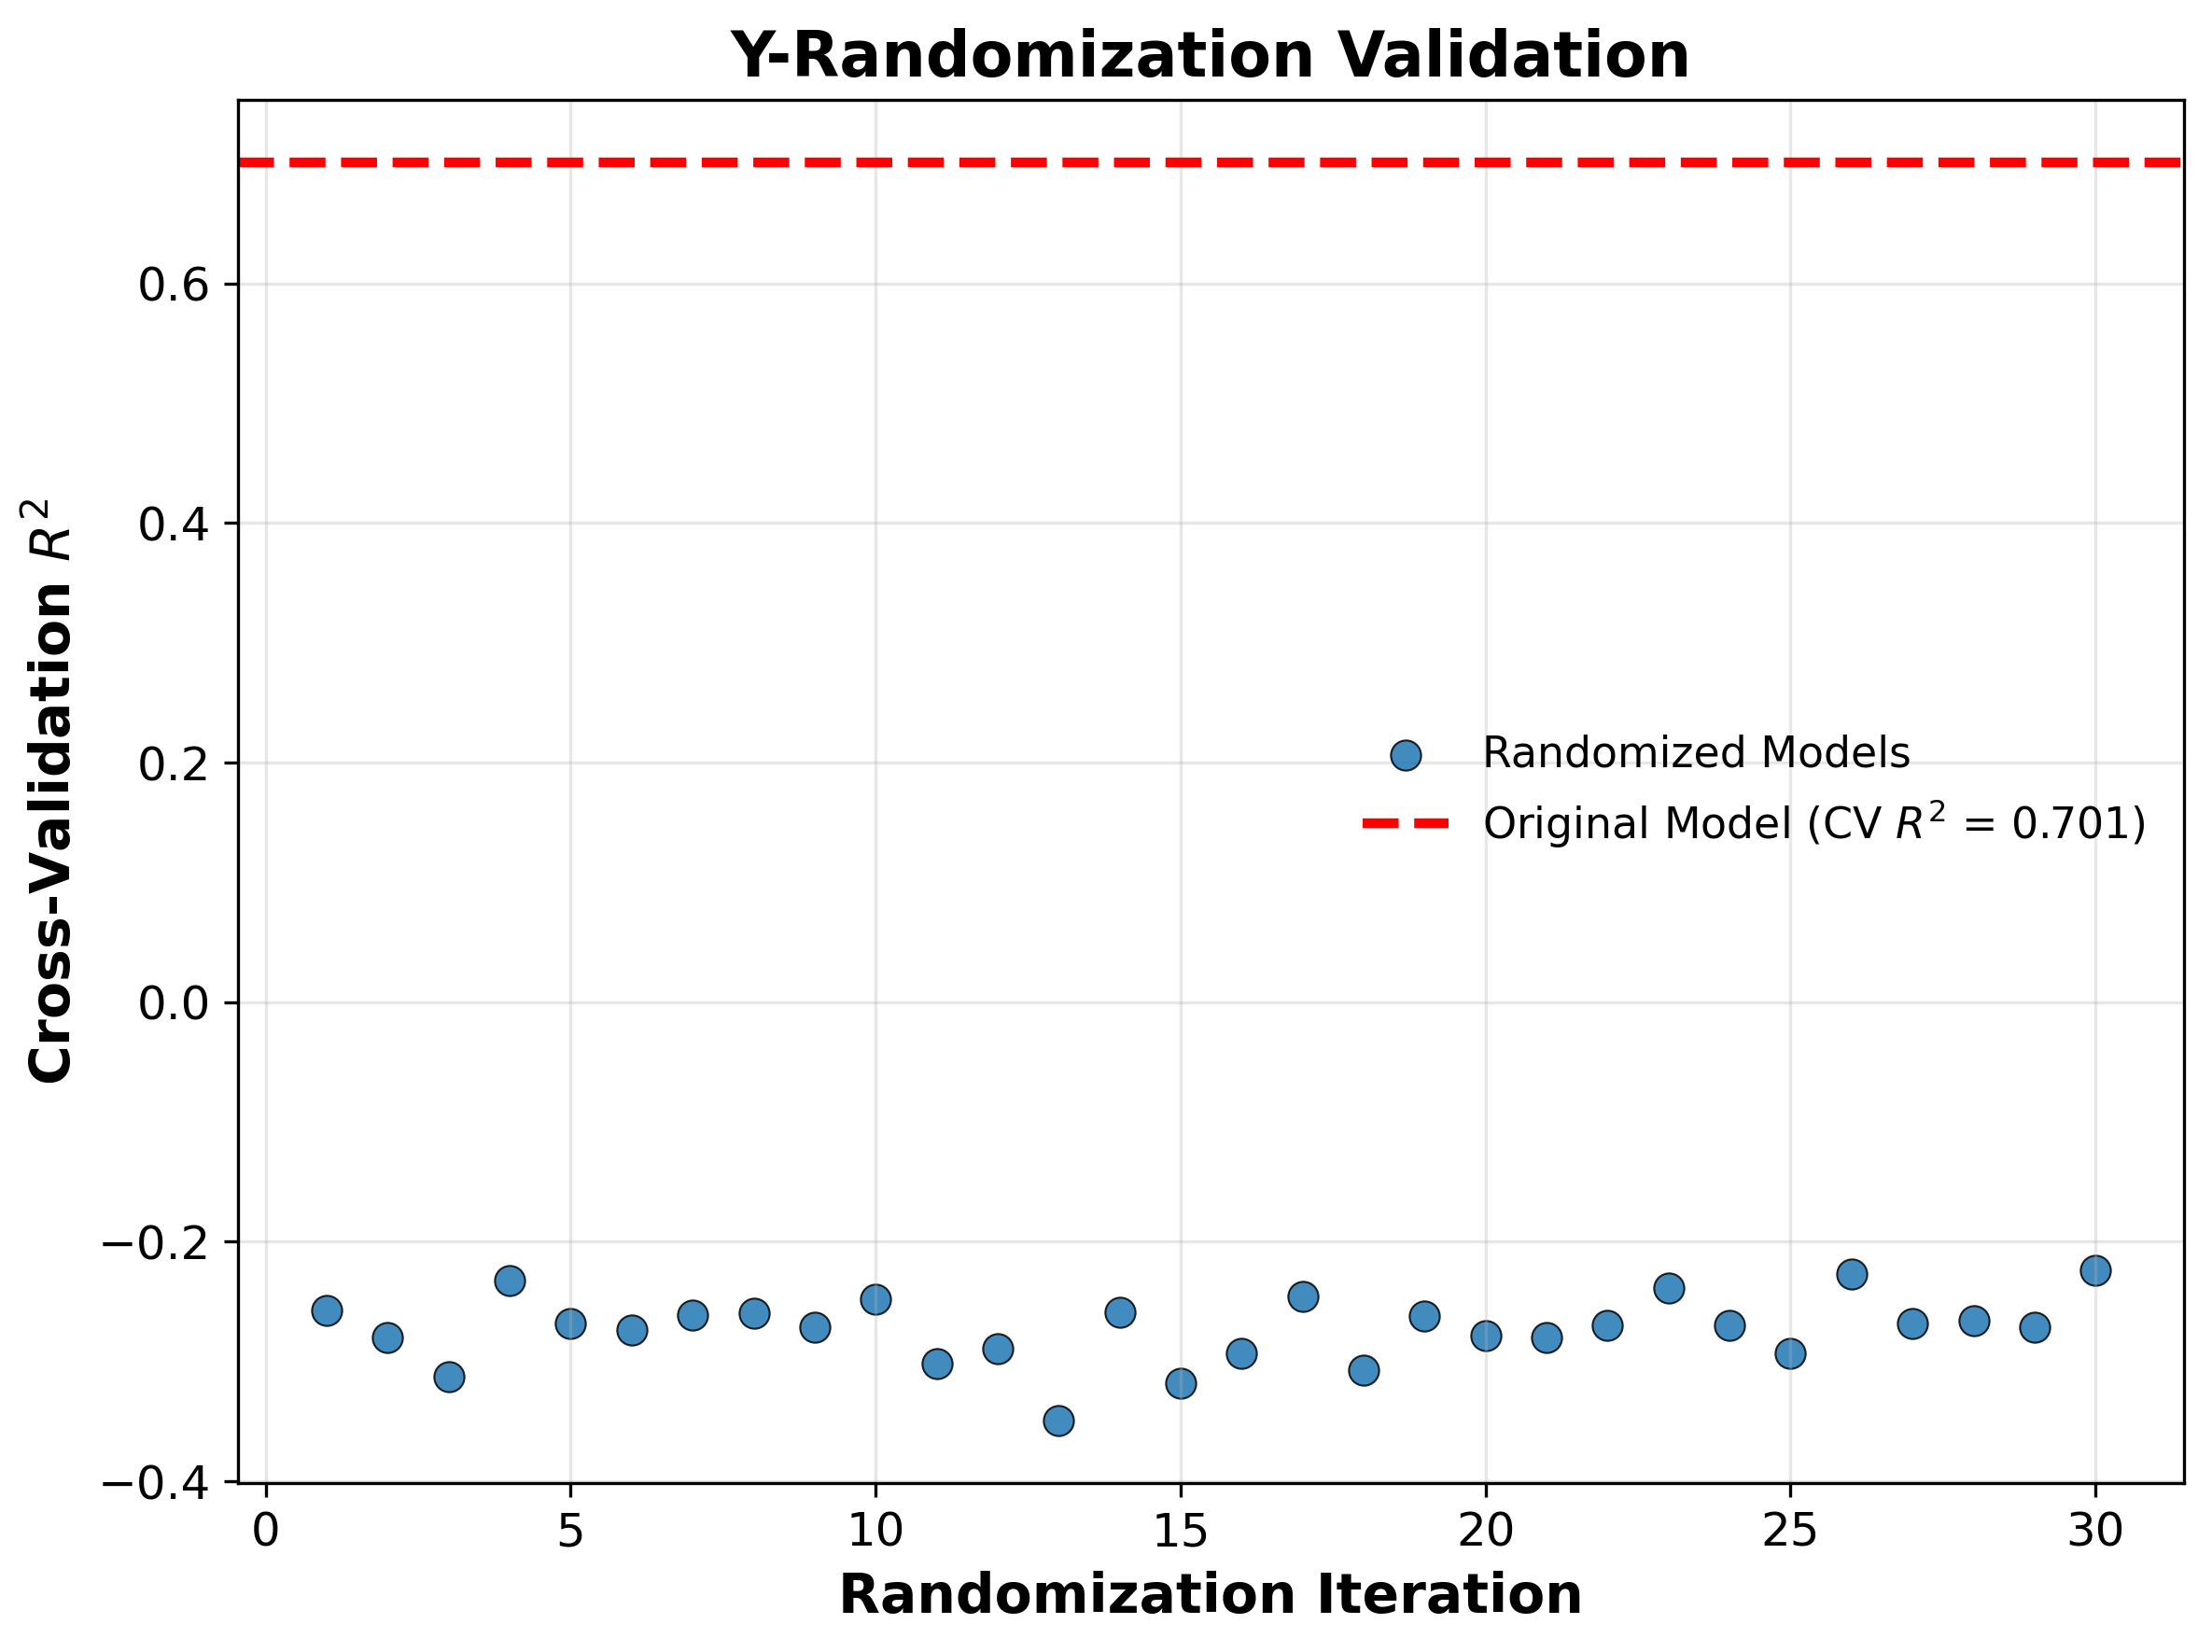

In [ ]:
# ==========================================================
# Publication-quality Y-Randomization Plot
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(8,6), dpi=300)

# Randomized models
ax.scatter(
    np.arange(1, len(random_r2)+1),
    random_r2,
    s=60,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
    label="Randomized Models"
)

# Original model
ax.axhline(
    y=study.best_value,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=f"Original Model (CV $R^2$ = {study.best_value:.3f})"
)

ax.set_xlabel(
    "Randomization Iteration",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Cross-Validation $R^2$",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Y-Randomization Validation",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.grid(alpha=0.3)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()

plt.savefig(
    "Y_Randomization_Validation.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Y_Randomization_Validation.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Y_Randomization_Validation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# Calculate Leverage Values
# ==========================================================

import numpy as np

# Training descriptor matrix
X = X_train_final.values

# Hat matrix
hat_matrix = X @ np.linalg.inv(X.T @ X) @ X.T

# Leverage values
leverage = np.diag(hat_matrix)

print("="*60)
print("Leverage values calculated successfully!")
print("="*60)

print(f"Number of compounds : {len(leverage)}")
print(f"Maximum leverage    : {leverage.max():.4f}")
print(f"Minimum leverage    : {leverage.min():.4f}")

Leverage values calculated successfully!
Number of compounds : 2665
Maximum leverage    : 0.3849
Minimum leverage    : 0.0049


In [ ]:
# ==========================================================
# Standardized Residuals
# ==========================================================

from scipy.stats import zscore

residuals = y_train - train_pred

standardized_residuals = zscore(residuals)

print("="*60)
print("Standardized residuals calculated!")
print("="*60)

Standardized residuals calculated!


In [ ]:
# ==========================================================
# Warning Leverage
# ==========================================================

p = X_train_final.shape[1]
n = X_train_final.shape[0]

h_star = (3 * (p + 1)) / n

print("="*60)
print(f"Number of descriptors : {p}")
print(f"Training compounds    : {n}")
print(f"Warning leverage h*   : {h_star:.4f}")
print("="*60)

Number of descriptors : 75
Training compounds    : 2665
Warning leverage h*   : 0.0856


In [ ]:
# ==========================================================
# Williams Plot
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(8,6), dpi=300)

ax.scatter(
    leverage,
    standardized_residuals,
    s=55,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.8
)

# Horizontal thresholds
ax.axhline(
    y=3,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.axhline(
    y=-3,
    color="red",
    linestyle="--",
    linewidth=2
)

# Vertical threshold
ax.axvline(
    x=h_star,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"$h^*$ = {h_star:.3f}"
)

ax.set_xlabel(
    "Leverage",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Standardized Residual",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Williams Plot",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(labelsize=12)

ax.grid(alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "Williams_Plot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Williams_Plot.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Williams_Plot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

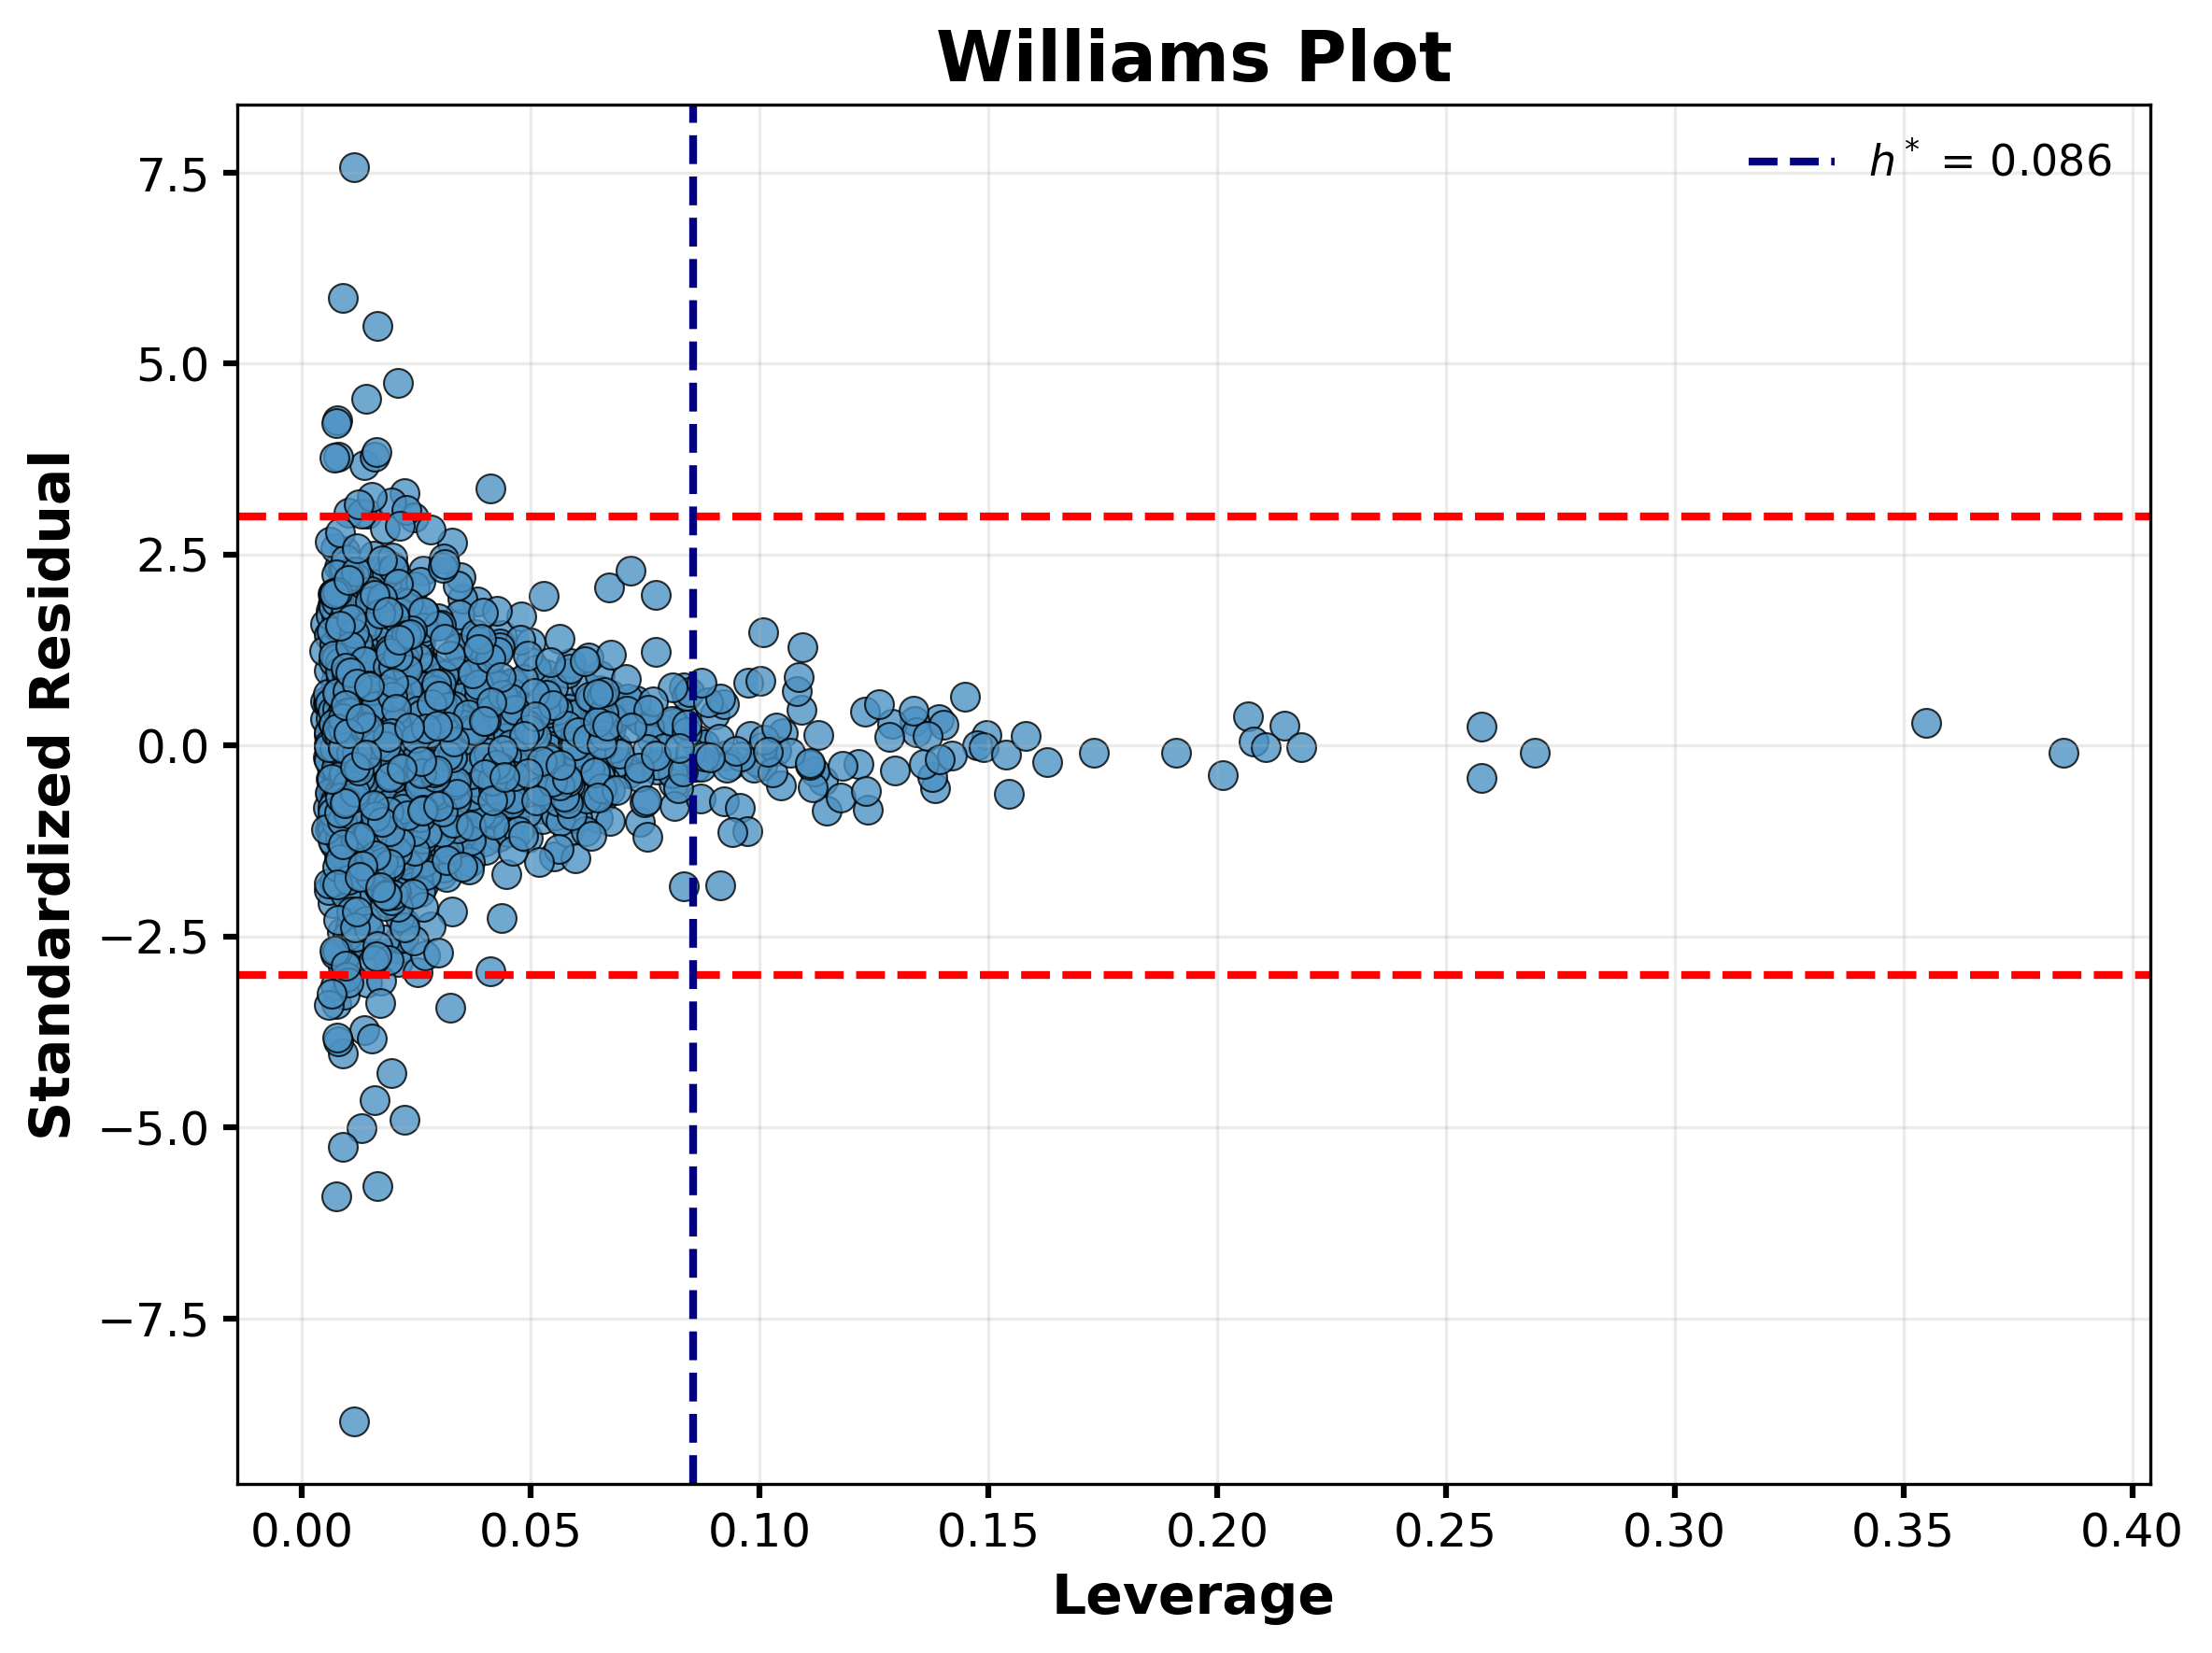

In [ ]:
# ==========================================================
# Publication-quality Williams Plot
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(8,6), dpi=300)

# Scatter plot
ax.scatter(
    leverage,
    standardized_residuals,
    s=55,
    facecolor="#4C92C3",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.80
)

# Response outlier limits
ax.axhline(
    y=3,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.axhline(
    y=-3,
    color="red",
    linestyle="--",
    linewidth=2
)

# Warning leverage
ax.axvline(
    x=h_star,
    color="navy",
    linestyle="--",
    linewidth=2,
    label=f"$h^*$ = {h_star:.3f}"
)

ax.set_xlabel(
    "Leverage",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Standardized Residual",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Williams Plot",
    fontsize=18,
    fontweight="bold"
)

ax.tick_params(
    labelsize=12,
    width=1.5
)

ax.grid(alpha=0.25)

ax.legend(
    frameon=False,
    fontsize=11,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "Williams_Plot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Williams_Plot.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Williams_Plot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# Count Applicability Domain Outliers
# ==========================================================

response_outliers = np.sum(
    np.abs(standardized_residuals) > 3
)

structural_outliers = np.sum(
    leverage > h_star
)

both_outliers = np.sum(
    (np.abs(standardized_residuals) > 3) &
    (leverage > h_star)
)

print("="*60)

print(f"Response outliers (> |3|): {response_outliers}")

print(f"High leverage compounds : {structural_outliers}")

print(f"Both conditions         : {both_outliers}")

print("="*60)

Response outliers (> |3|): 45
High leverage compounds : 94
Both conditions         : 0


In [ ]:
# ==========================================================
# Save Williams Plot Data
# ==========================================================

williams_df = pd.DataFrame({
    "Leverage": leverage,
    "Standardized_Residual": standardized_residuals
})

williams_df.to_csv(
    "Williams_Plot_Data.csv",
    index=False
)

print("Williams plot data saved successfully!")

Williams plot data saved successfully!
